# Generación de rutas peatonales con un Índice de Exposición al Riesgo

**Trabajo Final de Grado | Prototipado tecnológico**  
**Autor:** Agustín Vidaurreta

Este notebook documenta el flujo metodológico utilizado para construir y validar un prototipo de generación de rutas peatonales en la Ciudad Autónoma de Buenos Aires. El proceso integra registros delictivos históricos, análisis de calidad de datos, estimación de densidad espacial, asignación de un Índice de Exposición al Riesgo (IER) a la red peatonal y calibración de una función de costo que combina distancia y exposición relativa.

El IER es un indicador comparativo construido a partir de registros históricos oficiales. No representa una probabilidad individual de victimización ni garantiza la seguridad de un recorrido.

## Estructura y ejecución

El repositorio utiliza la siguiente organización:

```text
tfg-rutas-peatonales/
├── notebooks/
│   └── 01_pipeline_analitico.ipynb
├── app/
│   ├── app.py
│   ├── grafo_peatonal_con_ier.pkl
│   └── segmentos_ier_wgs84.pkl
├── config/
│   └── parametros_finales.json
├── data/
│   ├── raw/
│   └── processed/
├── outputs/
│   ├── figures/
│   ├── tables/
│   └── models/
├── docs/
├── README.md
└── requirements.txt
```

Los archivos CSV originales deben ubicarse en `data/raw/`. El notebook se ejecuta secuencialmente desde el inventario de fuentes hasta la exportación de los artefactos consumidos por la aplicación Streamlit. Las carpetas de salida se crean automáticamente cuando no existen.

## 0. Instalación de dependencias

Las dependencias del proyecto se encuentran en `requirements.txt`. Desde la raíz del repositorio pueden instalarse mediante:

```bash
python -m pip install -r requirements.txt
```

Después de instalar o actualizar librerías geoespaciales puede ser necesario reiniciar el kernel.

In [1]:
# Instalación opcional desde el notebook.
# Ejecutar únicamente cuando el entorno todavía no posea las dependencias.
# %pip install -r ../requirements.txt

## 1. Configuración general

Todos los parámetros del flujo se centralizan en esta sección. De esta manera, las decisiones metodológicas quedan visibles y pueden modificarse sin buscar valores dispersos en el notebook.


In [2]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import json
import math
import pickle
import random
import re
import shutil
import unicodedata
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from IPython.display import display
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from sklearn.model_selection import GroupKFold
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# ------------------------------------------------------------
# Rutas del proyecto
# ------------------------------------------------------------
DIRECTORIO_ACTUAL = Path.cwd().resolve()
if (DIRECTORIO_ACTUAL / 'data').exists():
    BASE_DIR = DIRECTORIO_ACTUAL
elif (DIRECTORIO_ACTUAL.parent / 'data').exists():
    BASE_DIR = DIRECTORIO_ACTUAL.parent
else:
    BASE_DIR = DIRECTORIO_ACTUAL
DATA_RAW_DIR = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
OUTPUT_DIR = BASE_DIR / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'
MODELS_DIR = OUTPUT_DIR / 'models'
APP_DIR = BASE_DIR / 'app'

for directorio in [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR,
    APP_DIR,
]:
    directorio.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Sistemas de referencia
# ------------------------------------------------------------
CRS_COORDENADAS = 'EPSG:4326'
CRS_METRICO = 'EPSG:32721'

# Límites aproximados utilizados como primer control de CABA.
LAT_MIN, LAT_MAX = -34.75, -34.50
LON_MIN, LON_MAX = -58.60, -58.30

# ------------------------------------------------------------
# Franjas horarias
# ------------------------------------------------------------
FRANJAS_HORARIAS = {
    'Madrugada': (0, 5),
    'Mañana': (6, 11),
    'Tarde': (12, 17),
    'Noche': (18, 23),
}

HORAS_POR_FRANJA = {
    'General': 24,
    'Madrugada': 6,
    'Mañana': 6,
    'Tarde': 6,
    'Noche': 6,
}

# ------------------------------------------------------------
# Parámetros candidatos para calibración
# ------------------------------------------------------------
TAMANIOS_CELDA_CANDIDATOS = [75, 100, 150, 200]
BANDWIDTHS_CANDIDATOS = [250, 350, 500, 750]
PASOS_MUESTREO_CANDIDATOS = [25, 50, 100]
AGREGACIONES_CANDIDATAS = ['media', 'maximo', 'percentil_75']
ALPHAS_CANDIDATOS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]

MARGEN_METROS = 3_000
TAMANIO_BLOQUE_CV_METROS = 2_000
MAX_PUNTOS_CALIBRACION_KDE = 30_000
MUESTRA_SEGMENTOS_CALIBRACION = 2_000
CANTIDAD_PARES_RUTA_PRUEBA = 30

# ------------------------------------------------------------
# PARÁMETROS FINALES SELECCIONADOS
# ------------------------------------------------------------
TAMANIO_CELDA_FINAL = 100
BANDWIDTH_FINAL = 750
PASO_MUESTREO_FINAL = 25
AGREGACION_FINAL = 'media'
ALPHA_FINAL = 3.0

print('Directorio base:', BASE_DIR)
print('Carpeta de datos originales:', DATA_RAW_DIR)


Directorio base: C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales
Carpeta de datos originales: C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales\data\raw


## 2. Inventario de fuentes

Esta sección identifica automáticamente los archivos disponibles y registra su tamaño, estructura, codificación y separador. El objetivo es detectar diferencias entre años antes de concatenar los datos.


In [3]:
def normalizar_texto(texto: object) -> str:
    if texto is None:
        return ''
    valor = unicodedata.normalize('NFKD', str(texto))
    valor = ''.join(c for c in valor if not unicodedata.combining(c))
    return valor


def normalizar_nombre_columna(nombre: object) -> str:
    valor = normalizar_texto(nombre).lower().strip()
    valor = re.sub(r'[^a-z0-9]+', '_', valor)
    return valor.strip('_')


def detectar_anio_desde_nombre(path: Path) -> float:
    coincidencia = re.search(r'(20\d{2})', path.stem)
    return int(coincidencia.group(1)) if coincidencia else np.nan


def leer_csv_robusto(path: Path) -> tuple[pd.DataFrame, dict]:
    """Intenta leer un CSV con diferentes codificaciones y separadores."""
    intentos = []
    codificaciones = ['utf-8', 'utf-8-sig', 'latin-1']

    for encoding in codificaciones:
        try:
            df = pd.read_csv(
                path,
                sep=None,
                engine='python',
                dtype=str,
                encoding=encoding,
                low_memory=False,
            )
            if df.shape[1] > 1:
                return df, {
                    'encoding': encoding,
                    'separador': 'detectado automáticamente',
                }
        except Exception as exc:
            intentos.append(f'{encoding}/auto: {exc}')

    for encoding in codificaciones:
        for separador in [';', ',', '\t', '|']:
            try:
                df = pd.read_csv(
                    path,
                    sep=separador,
                    dtype=str,
                    encoding=encoding,
                    low_memory=False,
                )
                if df.shape[1] > 1:
                    return df, {
                        'encoding': encoding,
                        'separador': repr(separador),
                    }
            except Exception as exc:
                intentos.append(f'{encoding}/{repr(separador)}: {exc}')

    detalle = '\n'.join(intentos[-6:])
    raise ValueError(f'No se pudo leer {path.name}. Últimos intentos:\n{detalle}')


ARCHIVOS_CSV = sorted(DATA_RAW_DIR.glob('*.csv'))

if not ARCHIVOS_CSV:
    print(
        'No se encontraron CSV en data/raw/. '
        'Copiá allí los archivos históricos y volvé a ejecutar esta celda.'
    )

inventario_registros = []
dataframes_crudos = {}

for path in ARCHIVOS_CSV:
    df, metadatos = leer_csv_robusto(path)
    dataframes_crudos[path.name] = df
    inventario_registros.append({
        'archivo': path.name,
        'anio_detectado': detectar_anio_desde_nombre(path),
        'registros': len(df),
        'columnas': df.shape[1],
        'encoding': metadatos['encoding'],
        'separador': metadatos['separador'],
        'nombres_columnas': ' | '.join(map(str, df.columns)),
    })

inventario_df = pd.DataFrame(inventario_registros)
display(inventario_df)

if not inventario_df.empty:
    inventario_df.to_csv(
        TABLES_DIR / 'inventario_fuentes.csv',
        index=False,
        encoding='utf-8-sig',
    )


,archivo,anio_detectado,registros,columnas,encoding,separador,nombres_columnas
0,delitos_2016 (1).csv,2016,154712,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
1,delitos_2017 (1).csv,2017,146938,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
2,delitos_2018 (1).csv,2018,149455,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
3,delitos_2019 (1).csv,2019,149524,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
4,delitos_2020 (1).csv,2020,86175,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
5,delitos_2021 (1).csv,2021,111962,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
6,delitos_2022 (1).csv,2022,140918,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
7,delitos_2023 (1).csv,2023,155897,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
8,delitos_2024 (2).csv,2024,158838,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...
9,delitos_2025 (2).csv,2025,133203,15,utf-8,"','",id-mapa | anio | mes | dia | fecha | franja | ...


## 3. Homogeneización de columnas y valores

Los archivos históricos pueden utilizar variantes en los nombres de sus columnas. Para integrarlos se define un esquema canónico y un conjunto de alias que estandariza las variables requeridas por el análisis espacial y temporal.

En los diez archivos analizados no fue necesario aplicar reglas particulares por año, ya que todos pudieron resolverse mediante el esquema general. La estructura admite incorporar equivalencias específicas si futuras fuentes presentan cambios adicionales. Las columnas no utilizadas por el modelo se conservan cuando es posible para mantener la trazabilidad.

In [4]:
COLUMNAS_CANONICAS = [
    'id_mapa',
    'anio',
    'mes',
    'dia',
    'fecha',
    'franja',
    'tipo',
    'subtipo',
    'uso_arma',
    'uso_moto',
    'barrio',
    'comuna',
    'latitud',
    'longitud',
    'cantidad',
]

ALIAS_COLUMNAS = {
    'id_mapa': ['id_mapa', 'id-mapa', 'idmapa', 'id_del_mapa'],
    'anio': ['anio', 'ano', 'año'],
    'mes': ['mes'],
    'dia': ['dia', 'día', 'dia_semana'],
    'fecha': ['fecha', 'fecha_hecho', 'fecha_del_hecho'],
    'franja': ['franja', 'hora', 'franja_horaria', 'hora_hecho'],
    'tipo': ['tipo', 'tipo_delito', 'tipo_de_delito'],
    'subtipo': ['subtipo', 'subtipo_delito', 'subtipo_de_delito'],
    'uso_arma': ['uso_arma', 'arma', 'uso_de_arma'],
    'uso_moto': ['uso_moto', 'moto', 'uso_de_moto'],
    'barrio': ['barrio'],
    'comuna': ['comuna'],
    'latitud': ['latitud', 'lat', 'latitude', 'latitud_wgs84'],
    'longitud': ['longitud', 'lon', 'lng', 'longitude', 'longitud_wgs84'],
    'cantidad': ['cantidad', 'cant', 'numero_de_hechos'],
}

RENOMBRES_ESPECIFICOS_POR_ARCHIVO = {}

VALORES_NULOS_CONOCIDOS = {
    '', ' ', 'nan', 'none', 'null', 's/d', 'sd', 'sin dato', 'sin datos', 'n/a', '-'
}


def construir_mapa_alias() -> dict[str, str]:
    resultado = {}
    for canonica, aliases in ALIAS_COLUMNAS.items():
        for alias in aliases + [canonica]:
            resultado[normalizar_nombre_columna(alias)] = canonica
    return resultado


MAPA_ALIAS = construir_mapa_alias()


def coalescer_columnas_duplicadas(df: pd.DataFrame) -> pd.DataFrame:
    if not df.columns.duplicated().any():
        return df

    columnas_finales = {}
    for nombre in pd.unique(df.columns):
        bloque = df.loc[:, df.columns == nombre]
        columnas_finales[nombre] = bloque.bfill(axis=1).iloc[:, 0]
    return pd.DataFrame(columnas_finales, index=df.index)


def homogeneizar_dataframe(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    resultado = df.copy()
    resultado.columns = [normalizar_nombre_columna(c) for c in resultado.columns]

    especificos = {
        normalizar_nombre_columna(origen): normalizar_nombre_columna(destino)
        for origen, destino in RENOMBRES_ESPECIFICOS_POR_ARCHIVO.get(path.name, {}).items()
    }
    resultado = resultado.rename(columns=especificos)
    resultado = resultado.rename(columns={c: MAPA_ALIAS.get(c, c) for c in resultado.columns})
    resultado = coalescer_columnas_duplicadas(resultado)

    for columna in COLUMNAS_CANONICAS:
        if columna not in resultado.columns:
            resultado[columna] = pd.NA

    for columna in resultado.columns:
        if resultado[columna].dtype == 'object':
            texto_normalizado = resultado[columna].astype('string').str.strip()
            resultado[columna] = texto_normalizado.mask(
                texto_normalizado.str.lower().isin(VALORES_NULOS_CONOCIDOS)
            )

    anio_nombre = detectar_anio_desde_nombre(path)
    anio_columna = pd.to_numeric(resultado['anio'], errors='coerce')
    resultado['anio_fuente'] = anio_columna.fillna(anio_nombre).astype('Int64')
    resultado['archivo_fuente'] = path.name
    resultado['fila_fuente'] = np.arange(1, len(resultado) + 1)

    return resultado


frames_homogeneizados = []
resumen_estructura = []

for path in ARCHIVOS_CSV:
    df_h = homogeneizar_dataframe(dataframes_crudos[path.name], path)
    frames_homogeneizados.append(df_h)

    faltantes_completas = [
        columna for columna in COLUMNAS_CANONICAS
        if df_h[columna].isna().all()
    ]
    resumen_estructura.append({
        'archivo': path.name,
        'registros': len(df_h),
        'columnas_canonicas_sin_datos': ', '.join(faltantes_completas),
    })

estructura_df = pd.DataFrame(resumen_estructura)
display(estructura_df)

if frames_homogeneizados:
    delitos_homogeneizados_df = pd.concat(
        frames_homogeneizados,
        ignore_index=True,
        sort=False,
    )
else:
    delitos_homogeneizados_df = pd.DataFrame()

print('Registros consolidados antes de limpieza:', f'{len(delitos_homogeneizados_df):,}')


,archivo,registros,columnas_canonicas_sin_datos
0,delitos_2016 (1).csv,154712,
1,delitos_2017 (1).csv,146938,
2,delitos_2018 (1).csv,149455,
3,delitos_2019 (1).csv,149524,
4,delitos_2020 (1).csv,86175,
5,delitos_2021 (1).csv,111962,
6,delitos_2022 (1).csv,140918,
7,delitos_2023 (1).csv,155897,
8,delitos_2024 (2).csv,158838,
9,delitos_2025 (2).csv,133203,


Registros consolidados antes de limpieza: 1,387,622


## 4. Limpieza y evaluación de calidad

La limpieza se documenta mediante variables de estado en lugar de descartar filas silenciosamente. Se distinguen registros utilizables para el modelo general y registros utilizables para el análisis temporal.

Los principales controles son:

- coordenadas faltantes, inválidas o fuera del rango aproximado de CABA;
- fechas no interpretables;
- horas o franjas inválidas;
- cantidades no numéricas;
- posibles duplicados;
- diferencias estructurales entre archivos.


In [5]:
def normalizar_coordenada_con_estado(
    valor: object,
    minimo_valido: float,
    maximo_valido: float,
    digitos_enteros: int = 2,
) -> tuple[float, str]:
    if pd.isna(valor) or str(valor).strip() == '':
        return np.nan, 'faltante'

    texto = str(valor).strip()

    try:
        numero = float(texto.replace(',', '.'))
        if minimo_valido <= numero <= maximo_valido:
            return numero, 'valida_directa'
        return np.nan, 'fuera_de_rango'
    except ValueError:
        pass

    signo = -1 if texto.startswith('-') else 1
    digitos = re.sub(r'\D', '', texto)

    if len(digitos) <= digitos_enteros:
        return np.nan, 'invalida'

    try:
        reconstruida = signo * float(
            f'{digitos[:digitos_enteros]}.{digitos[digitos_enteros:]}'
        )
    except ValueError:
        return np.nan, 'invalida'

    if minimo_valido <= reconstruida <= maximo_valido:
        return reconstruida, 'valida_reconstruida'

    return np.nan, 'fuera_de_rango'


def extraer_hora(valor: object) -> float:
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    coincidencia = re.search(r'(?<!\d)([01]?\d|2[0-3])(?!\d)', texto)
    if coincidencia:
        return float(coincidencia.group(1))

    try:
        hora = int(float(texto.replace(',', '.')))
        return float(hora) if 0 <= hora <= 23 else np.nan
    except ValueError:
        return np.nan


def clasificar_franja_horaria(hora: object) -> object:
    if pd.isna(hora):
        return pd.NA
    hora = int(hora)
    for nombre, (desde, hasta) in FRANJAS_HORARIAS.items():
        if desde <= hora <= hasta:
            return nombre
    return pd.NA


def normalizar_categoria(serie: pd.Series) -> pd.Series:
    return (
        serie.astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.upper()
    )


if delitos_homogeneizados_df.empty:
    raise RuntimeError('No hay datos consolidados. Revisá las secciones 2 y 3.')

trabajo_df = delitos_homogeneizados_df.copy()

lat_resultados = trabajo_df['latitud'].map(
    lambda valor: normalizar_coordenada_con_estado(valor, LAT_MIN, LAT_MAX)
)
lon_resultados = trabajo_df['longitud'].map(
    lambda valor: normalizar_coordenada_con_estado(valor, LON_MIN, LON_MAX)
)

trabajo_df['latitud_normalizada'] = [r[0] for r in lat_resultados]
trabajo_df['estado_latitud'] = [r[1] for r in lat_resultados]
trabajo_df['longitud_normalizada'] = [r[0] for r in lon_resultados]
trabajo_df['estado_longitud'] = [r[1] for r in lon_resultados]
trabajo_df['coordenada_valida'] = (
    trabajo_df['latitud_normalizada'].notna()
    & trabajo_df['longitud_normalizada'].notna()
)

trabajo_df['fecha_normalizada'] = pd.to_datetime(
    trabajo_df['fecha'],
    errors='coerce',
    dayfirst=True,
)
trabajo_df['fecha_valida'] = trabajo_df['fecha_normalizada'].notna()

trabajo_df['hora_normalizada'] = trabajo_df['franja'].map(extraer_hora)
trabajo_df['hora_valida'] = trabajo_df['hora_normalizada'].between(0, 23, inclusive='both')
trabajo_df['franja_agregada'] = trabajo_df['hora_normalizada'].map(clasificar_franja_horaria)

trabajo_df['cantidad_original_numerica'] = pd.to_numeric(
    trabajo_df['cantidad'], errors='coerce'
)
trabajo_df['cantidad_numerica'] = trabajo_df['cantidad_original_numerica'].fillna(1.0)
trabajo_df['cantidad_valida'] = trabajo_df['cantidad_original_numerica'].notna()

for columna in ['tipo', 'subtipo', 'uso_arma', 'uso_moto', 'barrio']:
    trabajo_df[f'{columna}_normalizado'] = normalizar_categoria(trabajo_df[columna])

# Criterio conservador para identificar duplicados potenciales.
columnas_duplicado = [
    'anio_fuente',
    'fecha_normalizada',
    'hora_normalizada',
    'latitud_normalizada',
    'longitud_normalizada',
    'tipo_normalizado',
    'subtipo_normalizado',
]
trabajo_df['duplicado_potencial'] = trabajo_df.duplicated(
    subset=columnas_duplicado,
    keep=False,
)

trabajo_df['utilizable_modelo_general'] = trabajo_df['coordenada_valida']
trabajo_df['utilizable_modelo_temporal'] = (
    trabajo_df['coordenada_valida'] & trabajo_df['hora_valida']
)

# Los duplicados se reportan, pero no se eliminan automáticamente hasta revisar
# si representan hechos distintos o duplicaciones reales de carga.
delitos_limpios_df = trabajo_df.loc[
    trabajo_df['utilizable_modelo_general']
].copy()

print('Registros originales consolidados:', f'{len(trabajo_df):,}')
print('Registros utilizables para KDE general:', f'{len(delitos_limpios_df):,}')
print(
    'Registros utilizables para KDE temporal:',
    f"{trabajo_df['utilizable_modelo_temporal'].sum():,}",
)


C:\Users\atvid\AppData\Local\Temp\ipykernel_25156\2559858284.py:95: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  trabajo_df['fecha_normalizada'] = pd.to_datetime(


Registros originales consolidados: 1,387,622
Registros utilizables para KDE general: 1,353,037
Registros utilizables para KDE temporal: 1,350,831


In [6]:
def construir_reporte_calidad(df: pd.DataFrame) -> pd.DataFrame:
    filas = []
    agrupadores = ['archivo_fuente', 'anio_fuente']

    for claves, grupo in df.groupby(agrupadores, dropna=False):
        archivo, anio = claves
        total = len(grupo)
        filas.append({
            'archivo': archivo,
            'anio': anio,
            'registros_originales': total,
            'coordenadas_validas': int(grupo['coordenada_valida'].sum()),
            'coordenadas_invalidas_o_faltantes': int((~grupo['coordenada_valida']).sum()),
            'porcentaje_coordenadas_validas': 100 * grupo['coordenada_valida'].mean(),
            'fechas_validas': int(grupo['fecha_valida'].sum()),
            'porcentaje_fechas_validas': 100 * grupo['fecha_valida'].mean(),
            'horas_validas': int(grupo['hora_valida'].sum()),
            'porcentaje_horas_validas': 100 * grupo['hora_valida'].mean(),
            'cantidad_no_numerica_o_faltante': int((~grupo['cantidad_valida']).sum()),
            'duplicados_potenciales': int(grupo['duplicado_potencial'].sum()),
            'registros_utilizables_general': int(grupo['utilizable_modelo_general'].sum()),
            'registros_utilizables_temporal': int(grupo['utilizable_modelo_temporal'].sum()),
        })

    return pd.DataFrame(filas).sort_values(['anio', 'archivo'])


reporte_calidad_df = construir_reporte_calidad(trabajo_df)
display(reporte_calidad_df)

reporte_calidad_df.to_csv(
    DATA_PROCESSED_DIR / 'reporte_calidad_por_archivo.csv',
    index=False,
    encoding='utf-8-sig',
)

# Porcentaje de faltantes por variable y año.
columnas_faltantes = [
    'fecha', 'franja', 'tipo', 'subtipo', 'uso_arma', 'uso_moto',
    'barrio', 'comuna', 'latitud', 'longitud', 'cantidad'
]

faltantes_por_anio_df = (
    trabajo_df.groupby('anio_fuente')[columnas_faltantes]
    .apply(lambda bloque: bloque.isna().mean().mul(100))
    .reset_index()
)

display(faltantes_por_anio_df)
faltantes_por_anio_df.to_csv(
    TABLES_DIR / 'faltantes_por_anio.csv',
    index=False,
    encoding='utf-8-sig',
)


,archivo,anio,registros_originales,coordenadas_validas,coordenadas_invalidas_o_faltantes,porcentaje_coordenadas_validas,fechas_validas,porcentaje_fechas_validas,horas_validas,porcentaje_horas_validas,cantidad_no_numerica_o_faltante,duplicados_potenciales,registros_utilizables_general,registros_utilizables_temporal
0,delitos_2016 (1).csv,2016,154712,154335,377,99.756321,154712,100.0,154708,99.997415,0,2650,154335,154331
1,delitos_2017 (1).csv,2017,146938,144157,2781,98.107365,146938,100.0,146932,99.995917,0,4227,144157,144154
2,delitos_2018 (1).csv,2018,149455,136297,13158,91.196012,149455,100.0,149450,99.996655,0,9719,136297,136292
3,delitos_2019 (1).csv,2019,149524,147366,2158,98.556753,149524,100.0,149517,99.995318,0,1468,147366,147359
4,delitos_2020 (1).csv,2020,86175,84877,1298,98.493763,86175,100.0,85656,99.397737,0,1361,84877,84376
5,delitos_2021 (1).csv,2021,111962,109381,2581,97.694754,111962,100.0,110222,98.445901,0,1758,109381,107885
6,delitos_2022 (1).csv,2022,140918,138528,2390,98.303978,140918,100.0,140871,99.966647,0,2212,138528,138527
7,delitos_2023 (1).csv,2023,155897,152755,3142,97.984567,155897,100.0,155897,100.000000,0,6175,152755,152755
8,delitos_2024 (2).csv,2024,158838,154920,3918,97.533336,158838,100.0,158791,99.970410,0,1635,154920,154879
9,delitos_2025 (2).csv,2025,133203,130421,2782,97.911458,133203,100.0,133048,99.883636,0,1883,130421,130273


,anio_fuente,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,2016,0.0,0.002585,0.0,0.0,0.0,0.0,0.254020,0.254020,0.224934,0.224934,0.0
1,2017,0.0,0.004083,0.0,0.0,0.0,0.0,1.953885,1.953885,1.106589,1.106589,0.0
2,2018,0.0,0.003345,0.0,0.0,0.0,0.0,8.834097,8.834097,8.795959,8.795959,0.0
3,2019,0.0,0.004682,0.0,0.0,0.0,0.0,1.444584,1.444584,1.442578,1.442578,0.0
4,2020,0.0,0.602263,0.0,0.0,0.0,0.0,1.507398,1.507398,1.506237,1.506237,0.0
5,2021,0.0,1.554099,0.0,0.0,0.0,0.0,2.307926,2.307926,2.303460,2.303460,0.0
6,2022,0.0,0.033353,0.0,0.0,0.0,0.0,1.696731,1.698151,1.692474,1.692474,0.0
7,2023,0.0,0.000000,0.0,0.0,0.0,0.0,2.025696,2.025696,0.223224,0.223224,0.0
8,2024,0.0,0.029590,0.0,0.0,0.0,0.0,2.469182,2.469182,2.413780,2.413780,0.0
9,2025,0.0,0.116364,0.0,0.0,0.0,0.0,2.090794,2.090794,0.198944,0.198944,0.0


### 4.1 Embudo de limpieza

El embudo resume cuántos registros permanecen disponibles después de cada control. La franja horaria se considera obligatoria solo para las superficies temporales, no para la superficie general.


In [7]:
total = len(trabajo_df)
con_columnas_clave = trabajo_df[['latitud', 'longitud']].notna().all(axis=1).sum()
con_coordenadas_validas = trabajo_df['coordenada_valida'].sum()
con_hora_valida = trabajo_df['utilizable_modelo_temporal'].sum()

embudo_calidad_df = pd.DataFrame([
    {'etapa': 'Registros originales consolidados', 'registros_restantes': total},
    {'etapa': 'Con latitud y longitud informadas', 'registros_restantes': con_columnas_clave},
    {'etapa': 'Con coordenadas interpretables dentro del rango', 'registros_restantes': con_coordenadas_validas},
    {'etapa': 'Con coordenadas y hora válidas', 'registros_restantes': con_hora_valida},
])
embudo_calidad_df['registros_excluidos_desde_etapa_anterior'] = (
    embudo_calidad_df['registros_restantes'].shift(1)
    - embudo_calidad_df['registros_restantes']
).fillna(0).astype(int)

display(embudo_calidad_df)
embudo_calidad_df.to_csv(
    TABLES_DIR / 'embudo_calidad.csv',
    index=False,
    encoding='utf-8-sig',
)


,etapa,registros_restantes,registros_excluidos_desde_etapa_anterior
0,Registros originales consolidados,1387622,0
1,Con latitud y longitud informadas,1359636,27986
2,Con coordenadas interpretables dentro del rango,1353037,6599
3,Con coordenadas y hora válidas,1350831,2206


### 4.2 Visualizaciones de calidad

Cada gráfico se genera en una figura independiente y se guarda en `outputs/figures/` para poder incorporarlo al informe o a los anexos.


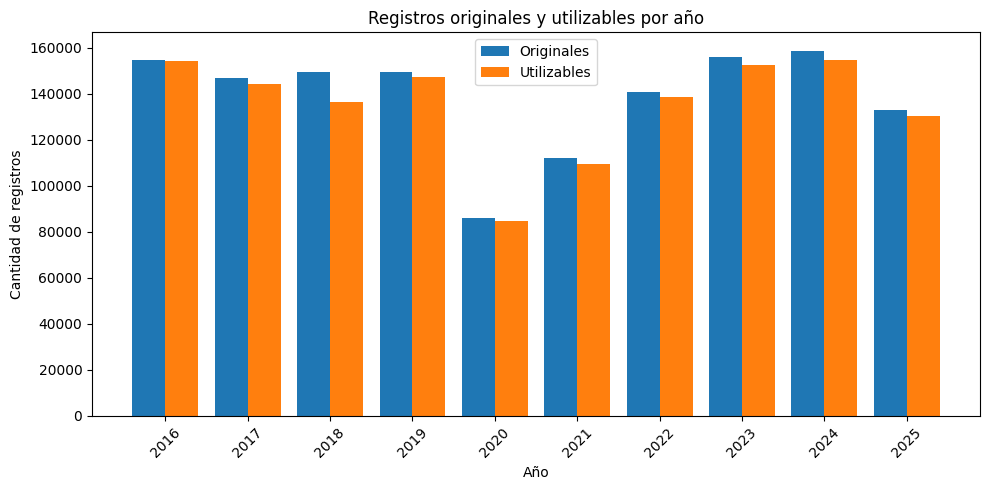

In [8]:
if not reporte_calidad_df.empty:
    grafico = reporte_calidad_df.groupby('anio', dropna=False).agg(
        registros_originales=('registros_originales', 'sum'),
        registros_utilizables=('registros_utilizables_general', 'sum'),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    posiciones = np.arange(len(grafico))
    ancho = 0.4
    ax.bar(posiciones - ancho / 2, grafico['registros_originales'], width=ancho, label='Originales')
    ax.bar(posiciones + ancho / 2, grafico['registros_utilizables'], width=ancho, label='Utilizables')
    ax.set_xticks(posiciones)
    ax.set_xticklabels(grafico['anio'].astype('Int64').astype(str), rotation=45)
    ax.set_title('Registros originales y utilizables por año')
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de registros')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'registros_originales_utilizables_por_anio.png', dpi=200)
    plt.show()


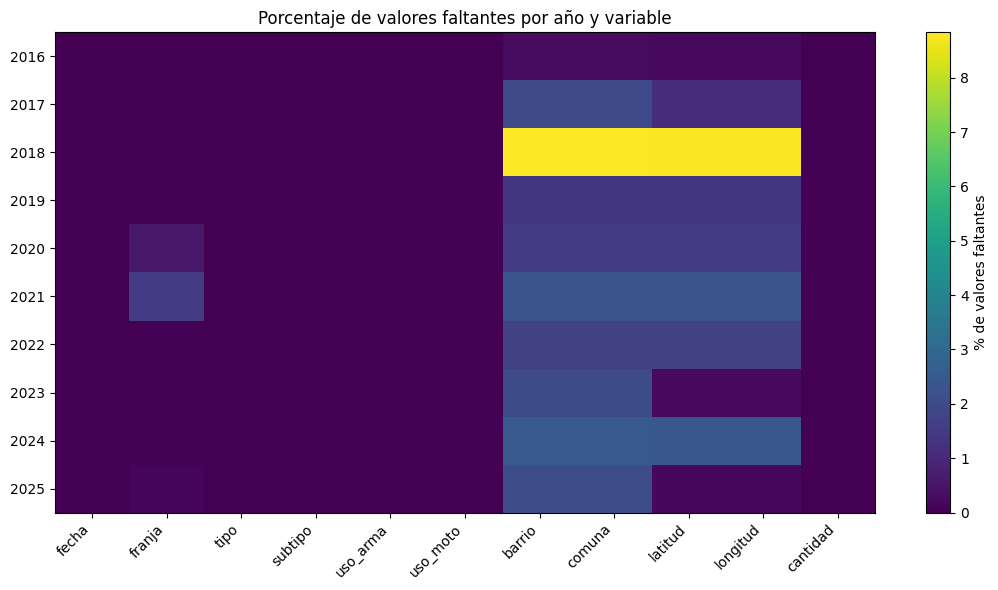

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
matriz_faltantes = faltantes_por_anio_df.set_index('anio_fuente')
imagen = ax.imshow(matriz_faltantes.values, aspect='auto')
ax.set_xticks(np.arange(len(matriz_faltantes.columns)))
ax.set_xticklabels(matriz_faltantes.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(matriz_faltantes.index)))
ax.set_yticklabels(matriz_faltantes.index.astype('Int64').astype(str))
ax.set_title('Porcentaje de valores faltantes por año y variable')
fig.colorbar(imagen, ax=ax, label='% de valores faltantes')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'faltantes_por_anio_variable.png', dpi=200)
plt.show()


## 5. Preparación geoespacial

Los registros originales se encuentran en coordenadas geográficas (`EPSG:4326`). Para construir superficies espaciales y medir distancias se proyectan a `EPSG:32721`, un sistema métrico apropiado para la ubicación de la Ciudad Autónoma de Buenos Aires.


In [10]:
delitos_gdf = gpd.GeoDataFrame(
    delitos_limpios_df.copy(),
    geometry=gpd.points_from_xy(
        delitos_limpios_df['longitud_normalizada'],
        delitos_limpios_df['latitud_normalizada'],
    ),
    crs=CRS_COORDENADAS,
)

delitos_metricos_gdf = delitos_gdf.to_crs(CRS_METRICO)

print('CRS geográfico:', delitos_gdf.crs)
print('CRS métrico:', delitos_metricos_gdf.crs)
print('Cantidad de eventos georreferenciados:', f'{len(delitos_metricos_gdf):,}')
print('Extensión métrica:', delitos_metricos_gdf.total_bounds)


CRS geográfico: EPSG:4326
CRS métrico: EPSG:32721
Cantidad de eventos georreferenciados: 1,353,037
Extensión métrica: [ 354023.79899944 6153564.94887856  377695.02136482 6180082.75046275]


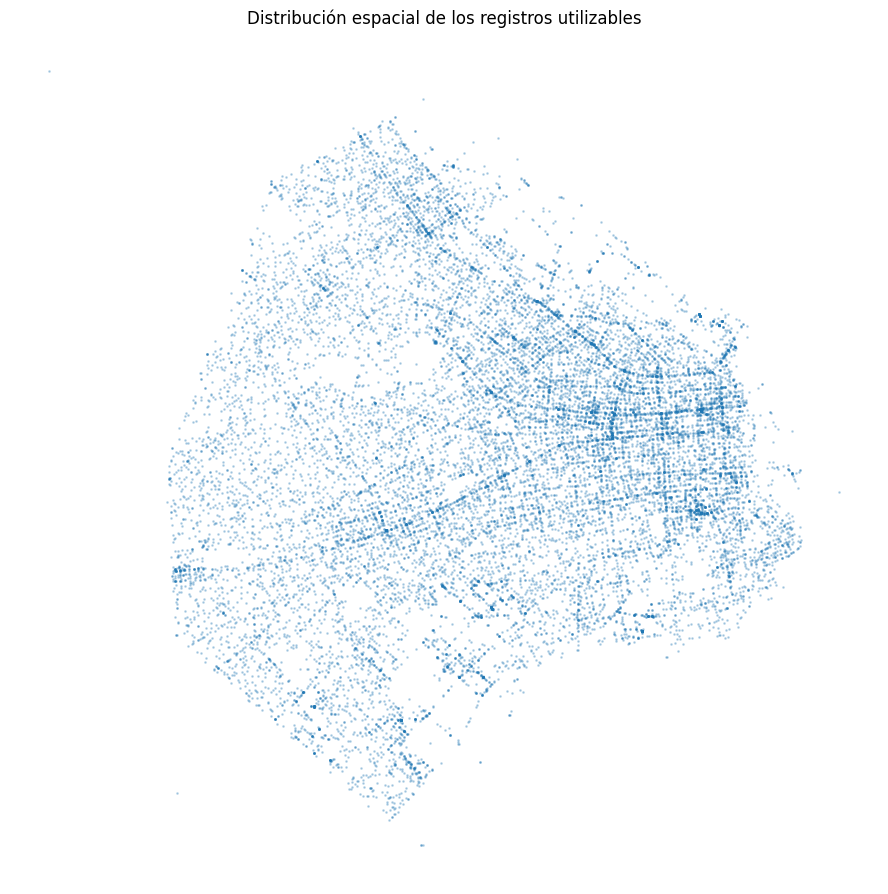

In [11]:
# Muestra espacial limitada por cuestiones de visibilidad.
muestra_mapa = delitos_metricos_gdf.sample(
    n=min(20_000, len(delitos_metricos_gdf)),
    random_state=SEMILLA,
)

fig, ax = plt.subplots(figsize=(9, 9))
muestra_mapa.plot(ax=ax, markersize=1, alpha=0.25)
ax.set_title('Distribución espacial de los registros utilizables')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'distribucion_espacial_registros.png', dpi=200)
plt.show()


## 6. Análisis exploratorio de datos

Esta sección describe la composición temporal y categórica de los registros antes de construir el IER. Las visualizaciones permiten detectar años incompletos, cambios abruptos en las categorías y franjas con volumen insuficiente.


,anio_fuente,registros
0,2016,154335
1,2017,144157
2,2018,136297
3,2019,147366
4,2020,84877
5,2021,109381
6,2022,138528
7,2023,152755
8,2024,154920
9,2025,130421


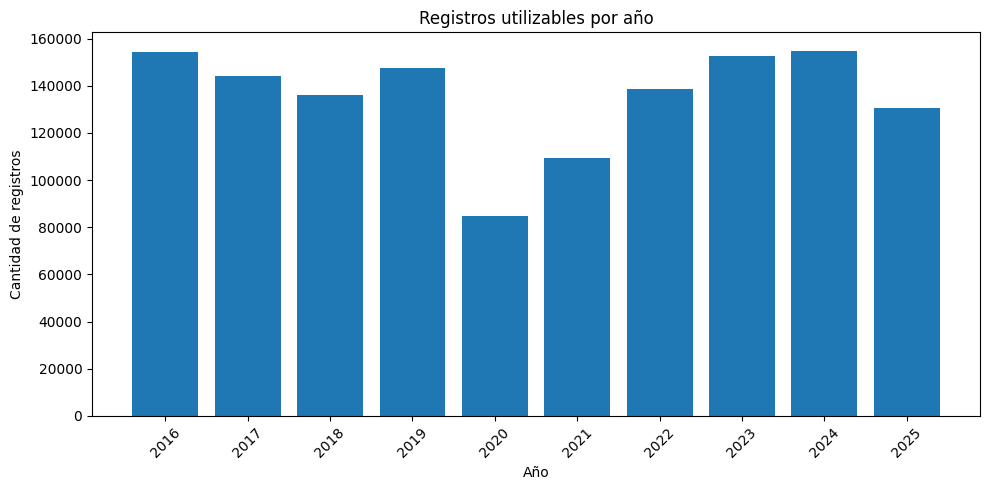

In [12]:
registros_por_anio_df = (
    delitos_metricos_gdf.groupby('anio_fuente')
    .size()
    .rename('registros')
    .reset_index()
)
display(registros_por_anio_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(registros_por_anio_df['anio_fuente'].astype(str), registros_por_anio_df['registros'])
ax.set_title('Registros utilizables por año')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de registros')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'registros_utilizables_por_anio.png', dpi=200)
plt.show()


,tipo,registros
0,ROBO,588186
1,HURTO,469157
2,LESIONES,115840
3,AMENAZAS,90083
4,VIALIDAD,88679
5,HOMICIDIOS,1092


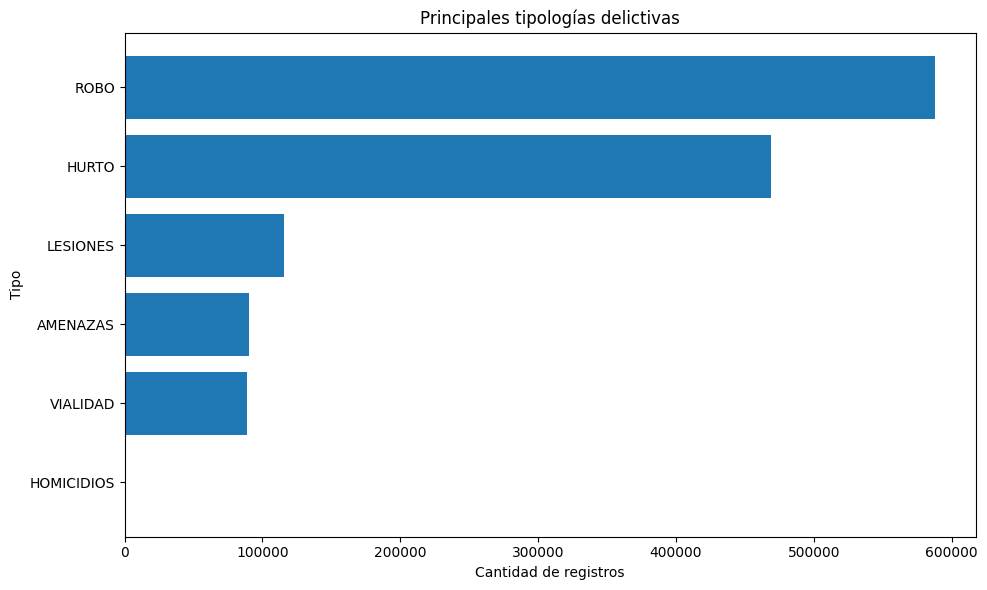

In [13]:
registros_por_tipo_df = (
    delitos_metricos_gdf['tipo_normalizado']
    .value_counts(dropna=False)
    .rename_axis('tipo')
    .reset_index(name='registros')
)
display(registros_por_tipo_df.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
top_tipos = registros_por_tipo_df.head(15).sort_values('registros')
ax.barh(top_tipos['tipo'].astype(str), top_tipos['registros'])
ax.set_title('Principales tipologías delictivas')
ax.set_xlabel('Cantidad de registros')
ax.set_ylabel('Tipo')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'principales_tipologias.png', dpi=200)
plt.show()


## 7. Definición y evaluación de franjas horarias

Se utilizan cuatro bloques de seis horas. La igualdad de duración facilita la comparación y la interpretación. Para construir las superficies temporales solo se emplean registros con hora válida.

La superficie **General** representa el conjunto completo de hechos georreferenciados. Las superficies temporales se ajustan por la cantidad de horas representadas y luego se normalizan con un máximo global común.


,anio_fuente,franja_agregada,registros
0,2016,Madrugada,20659
1,2016,Mañana,31340
2,2016,Noche,56227
3,2016,Tarde,46105
4,2017,Madrugada,24331
5,2017,Mañana,27580
6,2017,Noche,49924
7,2017,Tarde,42319
8,2018,Madrugada,15799
9,2018,Mañana,27053


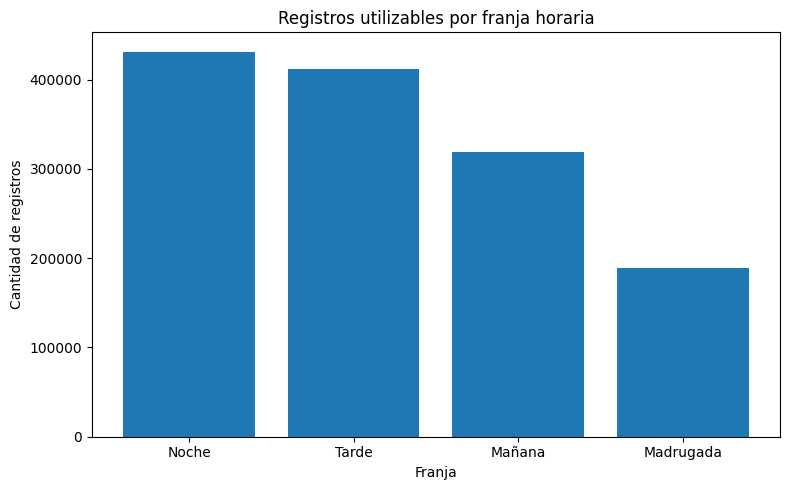

In [14]:
volumen_franjas_df = (
    delitos_metricos_gdf.loc[delitos_metricos_gdf['hora_valida']]
    .groupby(['anio_fuente', 'franja_agregada'], dropna=False)
    .size()
    .rename('registros')
    .reset_index()
)
display(volumen_franjas_df)

resumen_franjas_df = (
    volumen_franjas_df.groupby('franja_agregada')['registros']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen_franjas_df['franja_agregada'].astype(str), resumen_franjas_df['registros'])
ax.set_title('Registros utilizables por franja horaria')
ax.set_xlabel('Franja')
ax.set_ylabel('Cantidad de registros')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'registros_por_franja.png', dpi=200)
plt.show()


## 8. Construcción del KDE rasterizado

El procedimiento utilizado es una aproximación rasterizada a un estimador de densidad por kernel:

1. se cuentan los hechos dentro de una grilla regular;
2. se aplica un filtro gaussiano;
3. el `bandwidth` se expresa en metros y se convierte a cantidad de celdas;
4. la superficie se ajusta por las horas de cada franja;
5. todas las franjas se normalizan mediante un máximo global.

Este método es adecuado para explorar superficies continuas con un costo computacional moderado. Los parámetros se comparan mediante validación espacial y análisis de sensibilidad.


In [15]:
def crear_grilla(
    gdf: gpd.GeoDataFrame,
    tamanio_celda: float,
    margen: float,
) -> tuple[np.ndarray, np.ndarray]:
    xmin, ymin, xmax, ymax = gdf.total_bounds
    bordes_x = np.arange(
        xmin - margen,
        xmax + margen + tamanio_celda,
        tamanio_celda,
    )
    bordes_y = np.arange(
        ymin - margen,
        ymax + margen + tamanio_celda,
        tamanio_celda,
    )
    return bordes_x, bordes_y


def construir_kde_rasterizado(
    gdf: gpd.GeoDataFrame,
    bordes_x: np.ndarray,
    bordes_y: np.ndarray,
    tamanio_celda: float,
    bandwidth: float,
    columna_peso: str = 'cantidad_numerica',
) -> np.ndarray:
    if gdf.empty:
        return np.zeros((len(bordes_x) - 1, len(bordes_y) - 1), dtype=float)

    histograma, _, _ = np.histogram2d(
        gdf.geometry.x.to_numpy(),
        gdf.geometry.y.to_numpy(),
        bins=[bordes_x, bordes_y],
        weights=gdf[columna_peso].to_numpy(dtype=float),
    )

    sigma_celdas = bandwidth / tamanio_celda
    return gaussian_filter(histograma, sigma=sigma_celdas, mode='constant')


def construir_superficies_por_franja(
    gdf: gpd.GeoDataFrame,
    tamanio_celda: float,
    bandwidth: float,
    margen: float,
) -> dict:
    bordes_x, bordes_y = crear_grilla(gdf, tamanio_celda, margen)
    centros_x = (bordes_x[:-1] + bordes_x[1:]) / 2
    centros_y = (bordes_y[:-1] + bordes_y[1:]) / 2

    superficies_ajustadas = {}

    kde_general = construir_kde_rasterizado(
        gdf,
        bordes_x,
        bordes_y,
        tamanio_celda,
        bandwidth,
    )
    superficies_ajustadas['General'] = kde_general / HORAS_POR_FRANJA['General']

    for franja in FRANJAS_HORARIAS:
        subconjunto = gdf.loc[gdf['franja_agregada'] == franja]
        kde = construir_kde_rasterizado(
            subconjunto,
            bordes_x,
            bordes_y,
            tamanio_celda,
            bandwidth,
        )
        superficies_ajustadas[franja] = kde / HORAS_POR_FRANJA[franja]

    maximo_global = max(
        float(superficie.max()) for superficie in superficies_ajustadas.values()
    )
    if maximo_global <= 0:
        superficies_ier = {
            nombre: superficie.copy()
            for nombre, superficie in superficies_ajustadas.items()
        }
    else:
        superficies_ier = {
            nombre: superficie / maximo_global
            for nombre, superficie in superficies_ajustadas.items()
        }

    return {
        'bordes_x': bordes_x,
        'bordes_y': bordes_y,
        'centros_x': centros_x,
        'centros_y': centros_y,
        'superficies_ajustadas': superficies_ajustadas,
        'superficies_ier': superficies_ier,
        'maximo_global': maximo_global,
    }


## 9. Calibración del tamaño de celda y del bandwidth

La comparación utiliza validación cruzada por bloques espaciales. Los registros se agrupan en cuadrados del mismo tamaño y cada partición reserva bloques completos para evaluación. De esta manera se reduce la dependencia espacial entre entrenamiento y validación.

El indicador principal es la log-densidad media asignada a los eventos reservados. Valores mayores indican una mejor capacidad para representar datos no utilizados durante el ajuste. También se registran el tiempo de cómputo y el tamaño de la matriz.


In [16]:
def preparar_muestra_calibracion(
    gdf: gpd.GeoDataFrame,
    max_puntos: int,
) -> gpd.GeoDataFrame:
    if len(gdf) <= max_puntos:
        return gdf.copy()
    return gdf.sample(n=max_puntos, random_state=SEMILLA).copy()


def crear_grupos_espaciales(
    gdf: gpd.GeoDataFrame,
    tamanio_bloque: float,
) -> pd.Series:
    bloque_x = np.floor(gdf.geometry.x / tamanio_bloque).astype(int)
    bloque_y = np.floor(gdf.geometry.y / tamanio_bloque).astype(int)
    return bloque_x.astype(str) + '_' + bloque_y.astype(str)


def evaluar_configuracion_kde(
    gdf: gpd.GeoDataFrame,
    tamanio_celda: float,
    bandwidth: float,
    tamanio_bloque: float,
    n_splits: int = 5,
) -> dict:
    inicio = perf_counter()
    bordes_x, bordes_y = crear_grilla(gdf, tamanio_celda, MARGEN_METROS)
    centros_x = (bordes_x[:-1] + bordes_x[1:]) / 2
    centros_y = (bordes_y[:-1] + bordes_y[1:]) / 2

    grupos = crear_grupos_espaciales(gdf, tamanio_bloque)
    cantidad_grupos = grupos.nunique()
    splits_reales = min(n_splits, cantidad_grupos)
    if splits_reales < 2:
        raise ValueError('No hay suficientes bloques espaciales para validar.')

    cv = GroupKFold(n_splits=splits_reales)
    scores = []

    indices = np.arange(len(gdf))
    for train_idx, test_idx in cv.split(indices, groups=grupos):
        train = gdf.iloc[train_idx]
        test = gdf.iloc[test_idx]

        densidad = construir_kde_rasterizado(
            train,
            bordes_x,
            bordes_y,
            tamanio_celda,
            bandwidth,
        )
        suma = densidad.sum()
        if suma > 0:
            densidad = densidad / suma

        interpolador = RegularGridInterpolator(
            (centros_x, centros_y),
            densidad,
            bounds_error=False,
            fill_value=0.0,
        )
        coordenadas_test = np.column_stack([
            test.geometry.x.to_numpy(),
            test.geometry.y.to_numpy(),
        ])
        probabilidades = interpolador(coordenadas_test)
        scores.append(float(np.mean(np.log(probabilidades + 1e-12))))

    segundos = perf_counter() - inicio
    filas = len(bordes_y) - 1
    columnas = len(bordes_x) - 1

    return {
        'tamanio_celda_m': tamanio_celda,
        'bandwidth_m': bandwidth,
        'log_densidad_media_cv': float(np.mean(scores)),
        'desvio_score_cv': float(np.std(scores)),
        'tiempo_segundos': segundos,
        'filas_grilla': filas,
        'columnas_grilla': columnas,
        'cantidad_celdas': filas * columnas,
    }


In [17]:
muestra_kde_gdf = preparar_muestra_calibracion(
    delitos_metricos_gdf,
    MAX_PUNTOS_CALIBRACION_KDE,
)

resultados_kde = []
for tamanio_celda in tqdm(TAMANIOS_CELDA_CANDIDATOS, desc='Tamaños de celda'):
    for bandwidth in BANDWIDTHS_CANDIDATOS:
        resultados_kde.append(
            evaluar_configuracion_kde(
                muestra_kde_gdf,
                tamanio_celda=tamanio_celda,
                bandwidth=bandwidth,
                tamanio_bloque=TAMANIO_BLOQUE_CV_METROS,
            )
        )

comparacion_kde_df = (
    pd.DataFrame(resultados_kde)
    .sort_values('log_densidad_media_cv', ascending=False)
    .reset_index(drop=True)
)

display(comparacion_kde_df)
comparacion_kde_df.to_csv(
    TABLES_DIR / 'comparacion_parametros_kde.csv',
    index=False,
    encoding='utf-8-sig',
)


Tamaños de celda:   0%|          | 0/4 [00:00<?, ?it/s]

,tamanio_celda_m,bandwidth_m,log_densidad_media_cv,desvio_score_cv,tiempo_segundos,filas_grilla,columnas_grilla,cantidad_celdas
0,200,750,-9.001805,0.063796,0.447523,130,132,17160
1,200,500,-9.412050,0.069064,0.445333,130,132,17160
2,150,750,-9.578482,0.064025,0.453139,173,176,30448
3,200,350,-9.987854,0.099220,0.436100,130,132,17160
4,150,500,-9.993702,0.068857,0.407826,173,176,30448
5,100,750,-10.391517,0.064169,0.441778,259,263,68117
6,150,350,-10.586276,0.097215,0.408248,173,176,30448
7,100,500,-10.812044,0.070173,0.406108,259,263,68117
8,200,250,-10.847142,0.169519,0.445085,130,132,17160
9,75,750,-10.967769,0.064535,0.476714,346,351,121446


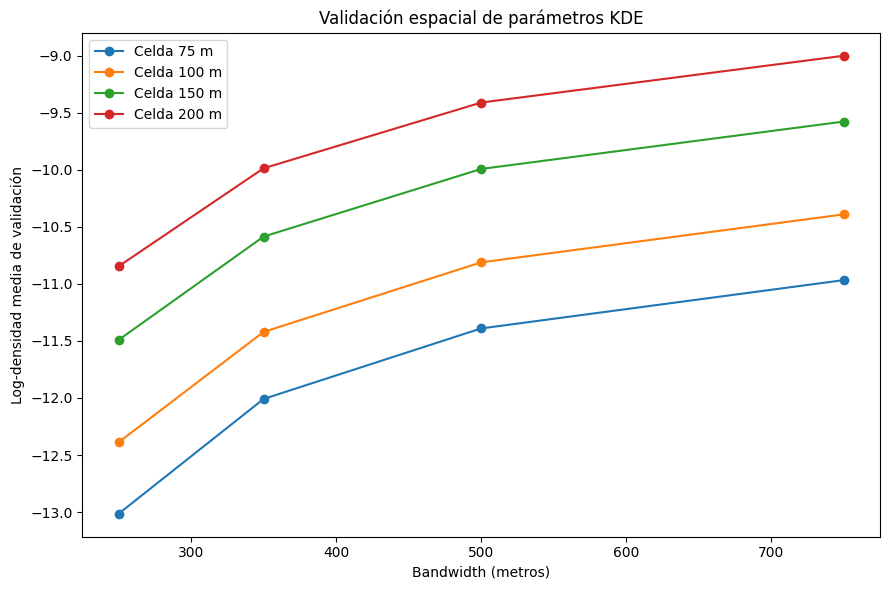

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
for tamanio_celda, bloque in comparacion_kde_df.groupby('tamanio_celda_m'):
    bloque = bloque.sort_values('bandwidth_m')
    ax.plot(
        bloque['bandwidth_m'],
        bloque['log_densidad_media_cv'],
        marker='o',
        label=f'Celda {tamanio_celda} m',
    )
ax.set_title('Validación espacial de parámetros KDE')
ax.set_xlabel('Bandwidth (metros)')
ax.set_ylabel('Log-densidad media de validación')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'comparacion_parametros_kde.png', dpi=200)
plt.show()


### 9.1 Inspección visual de configuraciones candidatas

La validación espacial se complementa con una revisión visual. La elección final debe evitar tanto superficies demasiado fragmentadas como suavizados que eliminen diferencias locales relevantes.


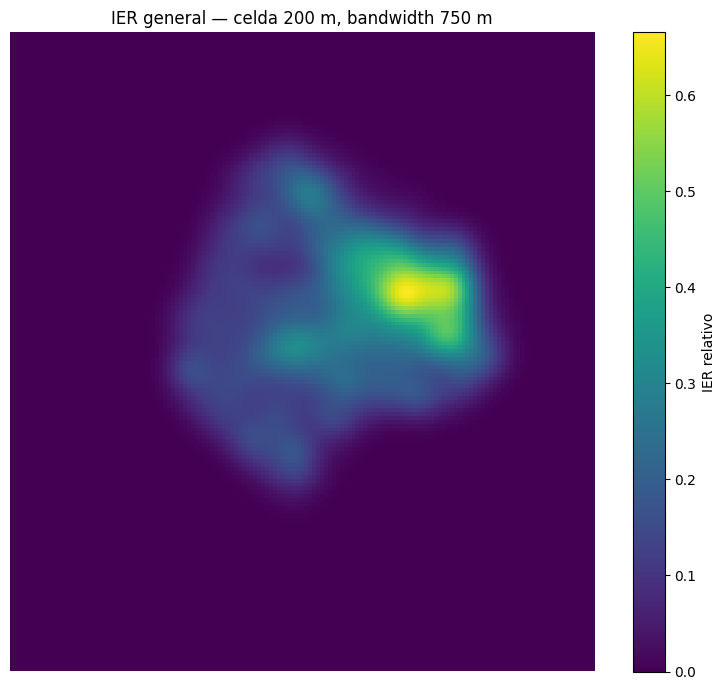

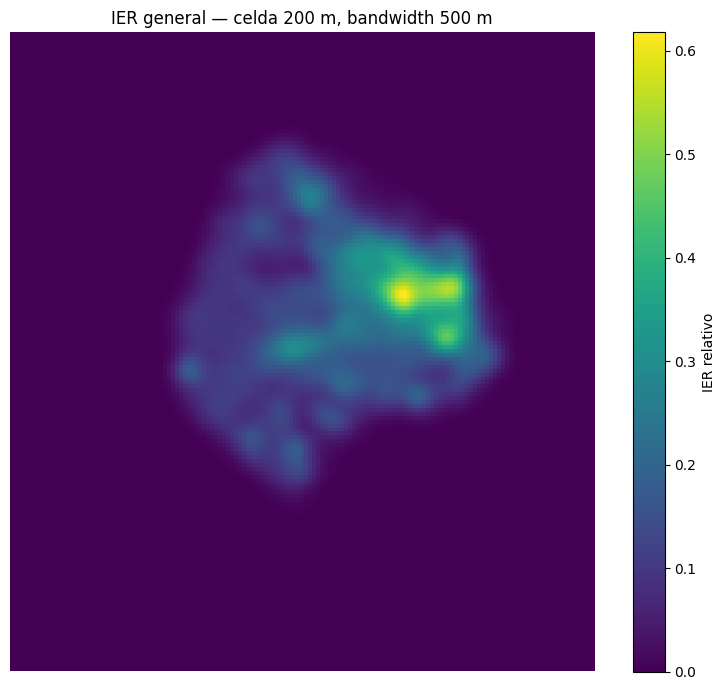

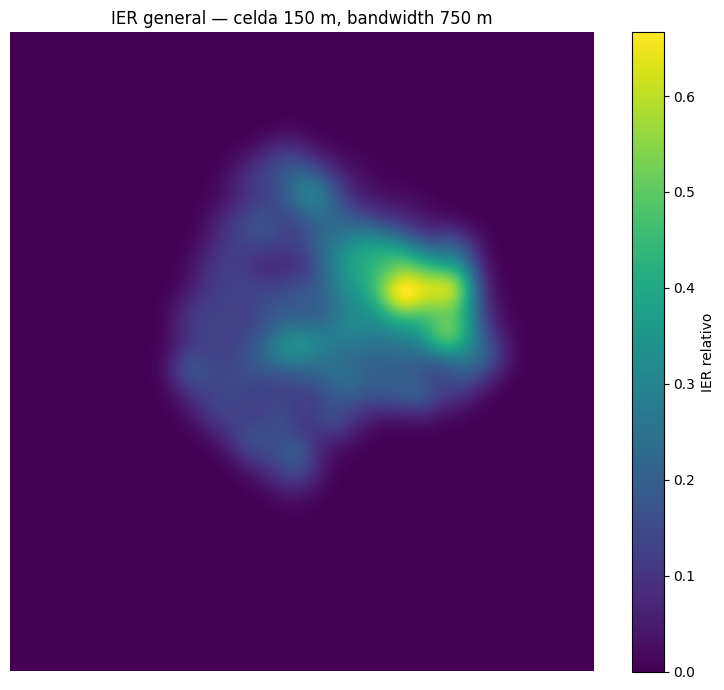

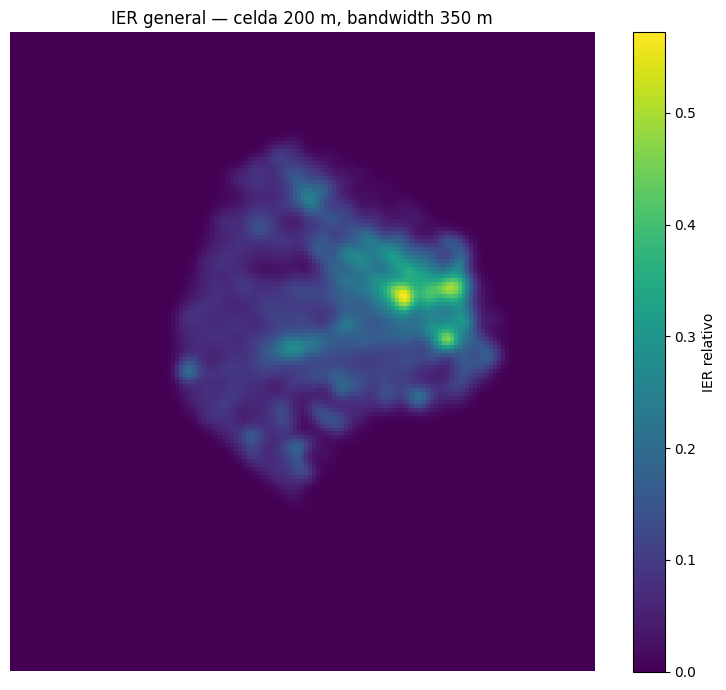

In [19]:
for _, fila in comparacion_kde_df.head(4).iterrows():
    resultado = construir_superficies_por_franja(
        delitos_metricos_gdf,
        tamanio_celda=float(fila['tamanio_celda_m']),
        bandwidth=float(fila['bandwidth_m']),
        margen=MARGEN_METROS,
    )
    superficie = resultado['superficies_ier']['General']

    fig, ax = plt.subplots(figsize=(8, 7))
    imagen = ax.imshow(
        superficie.T,
        origin='lower',
        extent=[
            resultado['bordes_x'][0], resultado['bordes_x'][-1],
            resultado['bordes_y'][0], resultado['bordes_y'][-1],
        ],
        aspect='equal',
    )
    ax.set_title(
        f"IER general — celda {fila['tamanio_celda_m']:.0f} m, "
        f"bandwidth {fila['bandwidth_m']:.0f} m"
    )
    ax.set_axis_off()
    fig.colorbar(imagen, ax=ax, label='IER relativo')
    fig.tight_layout()
    plt.show()


## 10. Selección y construcción de las superficies finales

Se seleccionó una grilla de **100 metros**, un `bandwidth` de **750 metros** y un margen de **3000 metros**.

El ancho de banda de 750 metros obtuvo el mejor desempeño de validación dentro de todos los tamaños de celda analizados y presentó una variabilidad reducida entre particiones espaciales. La celda de 100 metros alcanzó el menor desvío del score entre las configuraciones con ese ancho de banda y preservó mayor detalle espacial que las grillas de 150 y 200 metros. La grilla de 75 metros no produjo una mejora en estabilidad y solo aumentó la resolución de una superficie ya suavizada.

El margen se fijó en cuatro veces el ancho de banda. De esta manera, la grilla contiene el alcance efectivo del filtro gaussiano y reduce el truncamiento numérico próximo a sus bordes. Este margen no incorpora registros externos a CABA y, por lo tanto, no elimina las limitaciones asociadas a la ausencia de datos de jurisdicciones vecinas.

In [20]:
resultado_superficies = construir_superficies_por_franja(
    delitos_metricos_gdf,
    tamanio_celda=TAMANIO_CELDA_FINAL,
    bandwidth=BANDWIDTH_FINAL,
    margen=MARGEN_METROS,
)

bordes_x = resultado_superficies['bordes_x']
bordes_y = resultado_superficies['bordes_y']
centros_x = resultado_superficies['centros_x']
centros_y = resultado_superficies['centros_y']
superficies_ier = resultado_superficies['superficies_ier']
maximo_global_kde = resultado_superficies['maximo_global']

resumen_superficies_df = pd.DataFrame([
    {
        'franja': nombre,
        'maximo_ier': float(superficie.max()),
        'media_ier': float(superficie.mean()),
        'mediana_ier': float(np.median(superficie)),
        'percentil_95_ier': float(np.percentile(superficie, 95)),
    }
    for nombre, superficie in superficies_ier.items()
])
display(resumen_superficies_df)
resumen_superficies_df.to_csv(
    TABLES_DIR / 'resumen_superficies_ier.csv',
    index=False,
    encoding='utf-8-sig',
)


,franja,maximo_ier,media_ier,mediana_ier,percentil_95_ier
0,General,0.666017,0.042816,3.995467e-06,0.251504
1,Madrugada,0.339903,0.023908,4.659936e-07,0.138081
2,Mañana,0.527824,0.040331,2.323099e-06,0.243012
3,Tarde,1.000000,0.052134,1.055316e-06,0.306416
4,Noche,0.820706,0.054612,3.518550e-06,0.322891


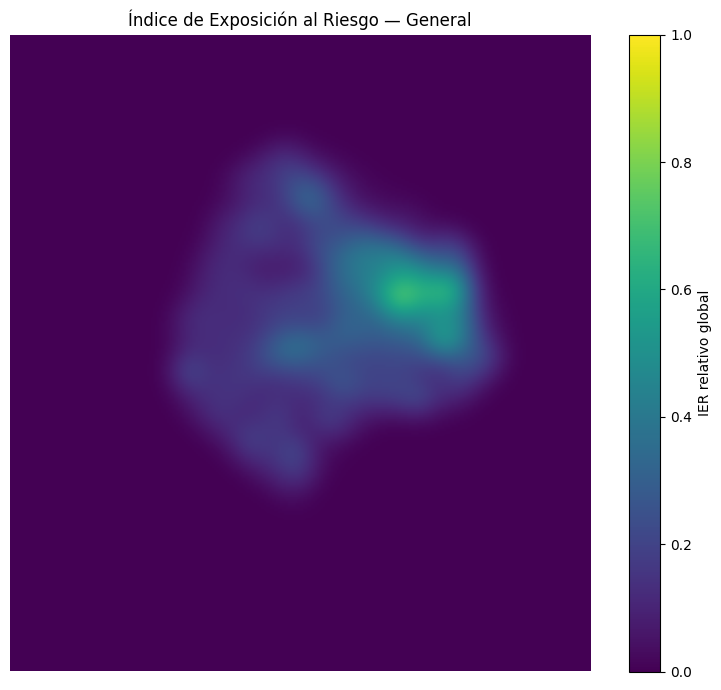

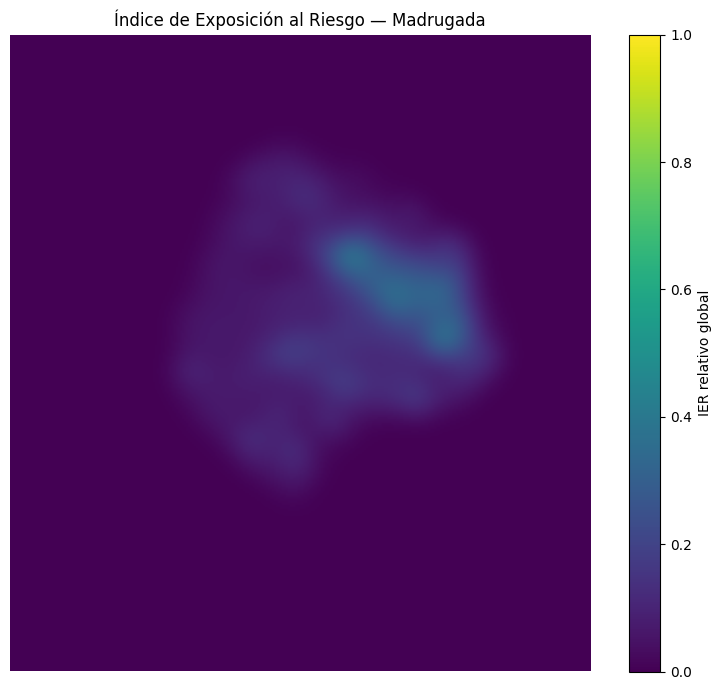

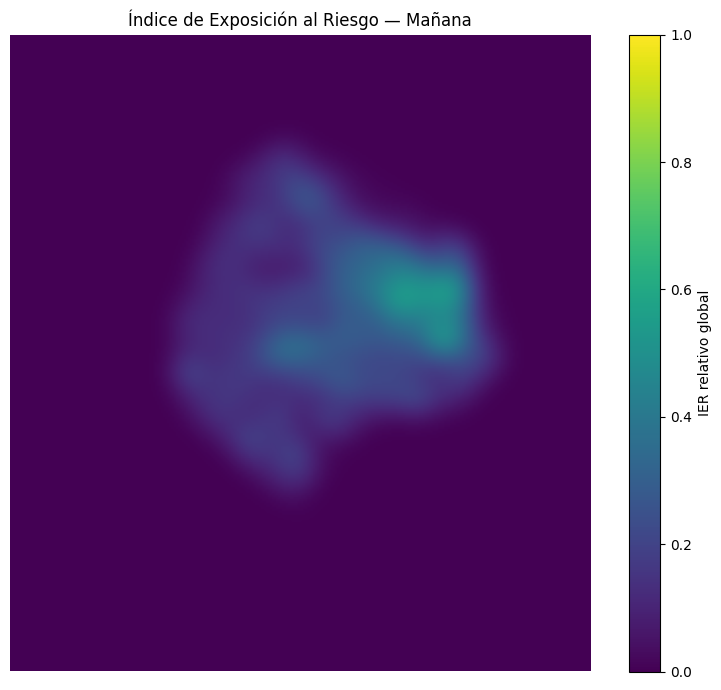

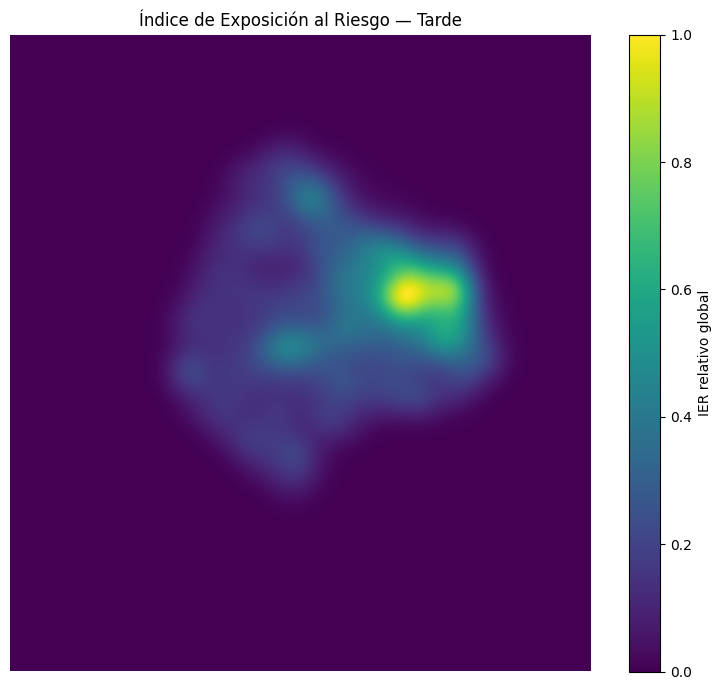

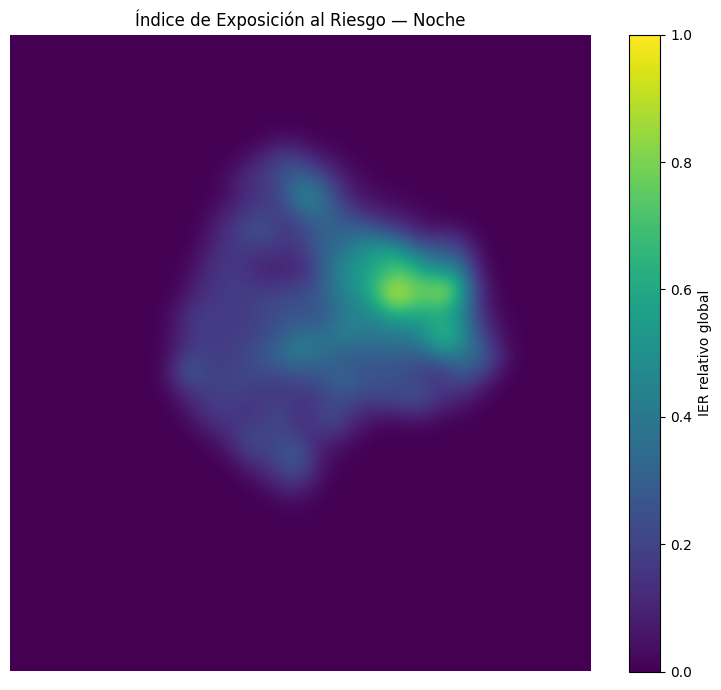

In [21]:
for nombre, superficie in superficies_ier.items():
    fig, ax = plt.subplots(figsize=(8, 7))
    imagen = ax.imshow(
        superficie.T,
        origin='lower',
        extent=[bordes_x[0], bordes_x[-1], bordes_y[0], bordes_y[-1]],
        aspect='equal',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'Índice de Exposición al Riesgo — {nombre}')
    ax.set_axis_off()
    fig.colorbar(imagen, ax=ax, label='IER relativo global')
    fig.tight_layout()
    nombre_archivo = normalizar_nombre_columna(nombre)
    fig.savefig(FIGURES_DIR / f'ier_superficie_{nombre_archivo}.png', dpi=200)
    plt.show()


## 11. Obtención y validación de la red peatonal

La red se descarga desde OpenStreetMap mediante OSMnx y se almacena localmente para evitar repetir la consulta en cada ejecución. Se utiliza `network_type="walk"`, ya que el prototipo está orientado a desplazamientos peatonales.


In [22]:
GRAPHML_PATH = MODELS_DIR / 'grafo_peatonal_caba.graphml'

if GRAPHML_PATH.exists():
    grafo_peatonal = ox.load_graphml(GRAPHML_PATH)
    print('Grafo cargado desde:', GRAPHML_PATH)
else:
    grafo_peatonal = ox.graph_from_place(
        'Ciudad Autónoma de Buenos Aires, Argentina',
        network_type='walk',
        retain_all=False,
    )
    ox.save_graphml(grafo_peatonal, GRAPHML_PATH)
    print('Grafo descargado y guardado en:', GRAPHML_PATH)

grafo_peatonal_metrico = ox.project_graph(grafo_peatonal, to_crs=CRS_METRICO)
nodos_metricos_gdf, segmentos_metricos_gdf = ox.graph_to_gdfs(
    grafo_peatonal_metrico,
    nodes=True,
    edges=True,
)

print('Cantidad de nodos:', f'{len(nodos_metricos_gdf):,}')
print('Cantidad de segmentos dirigidos:', f'{len(segmentos_metricos_gdf):,}')
print('CRS de la red:', segmentos_metricos_gdf.crs)


Grafo descargado y guardado en: C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales\outputs\models\grafo_peatonal_caba.graphml
Cantidad de nodos: 45,386
Cantidad de segmentos dirigidos: 140,286
CRS de la red: EPSG:32721


In [23]:
componentes_debiles = list(nx.weakly_connected_components(grafo_peatonal_metrico))
tamanios_componentes = sorted((len(c) for c in componentes_debiles), reverse=True)

resumen_red_df = pd.DataFrame({
    'metrica': [
        'nodos',
        'segmentos',
        'componentes_debiles',
        'nodos_componente_principal',
        'segmentos_sin_longitud',
    ],
    'valor': [
        len(grafo_peatonal_metrico.nodes),
        len(grafo_peatonal_metrico.edges),
        len(componentes_debiles),
        tamanios_componentes[0] if tamanios_componentes else 0,
        int(segmentos_metricos_gdf['length'].isna().sum()),
    ],
})
display(resumen_red_df)
resumen_red_df.to_csv(
    TABLES_DIR / 'validacion_red_peatonal.csv',
    index=False,
    encoding='utf-8-sig',
)


,metrica,valor
0,nodos,45386
1,segmentos,140286
2,componentes_debiles,1
3,nodos_componente_principal,45386
4,segmentos_sin_longitud,0


## 12. Asignación del IER a los segmentos

Cada segmento se muestrea a intervalos regulares. En cada punto se interpola el valor de la superficie KDE y luego se resume el conjunto de valores.

Se comparan tres pasos de muestreo y tres métodos de agregación:

- **media:** aproxima la exposición promedio a lo largo del segmento;
- **máximo:** prioriza el punto de mayor exposición, pero puede ser sensible a valores aislados;
- **percentil 75:** otorga mayor importancia a valores elevados sin depender de un único máximo.


In [24]:
def construir_interpoladores(
    centros_x: np.ndarray,
    centros_y: np.ndarray,
    superficies: dict[str, np.ndarray],
) -> dict[str, RegularGridInterpolator]:
    return {
        nombre: RegularGridInterpolator(
            (centros_x, centros_y),
            superficie,
            bounds_error=False,
            fill_value=0.0,
        )
        for nombre, superficie in superficies.items()
    }


def resumir_valores(valores: np.ndarray, metodo: str) -> float:
    valores = valores[np.isfinite(valores)]
    if len(valores) == 0:
        return np.nan
    if metodo == 'media':
        return float(np.mean(valores))
    if metodo == 'maximo':
        return float(np.max(valores))
    if metodo == 'percentil_75':
        return float(np.percentile(valores, 75))
    raise ValueError(f'Método de agregación desconocido: {metodo}')


def calcular_ier_segmento(
    geometria,
    interpolador: RegularGridInterpolator,
    paso_metros: float,
    metodo_agregacion: str,
) -> float:
    if geometria is None or geometria.is_empty:
        return np.nan

    longitud = float(geometria.length)
    if longitud <= 0:
        return np.nan

    distancias = np.arange(0, longitud + paso_metros, paso_metros)
    distancias = np.unique(np.clip(distancias, 0, longitud))
    puntos = [geometria.interpolate(d) for d in distancias]
    coordenadas = np.array([[p.x, p.y] for p in puntos])
    valores = interpolador(coordenadas)
    return resumir_valores(valores, metodo_agregacion)


interpoladores_ier = construir_interpoladores(
    centros_x,
    centros_y,
    superficies_ier,
)

segmentos_base_gdf = segmentos_metricos_gdf.reset_index().copy()


In [25]:
muestra_segmentos_gdf = segmentos_base_gdf.sample(
    n=min(MUESTRA_SEGMENTOS_CALIBRACION, len(segmentos_base_gdf)),
    random_state=SEMILLA,
).copy()

resultados_muestreo = {}
tiempos_muestreo = {}
interpolador_general = interpoladores_ier['General']

for paso in PASOS_MUESTREO_CANDIDATOS:
    for agregacion in AGREGACIONES_CANDIDATAS:
        clave = (paso, agregacion)
        inicio = perf_counter()
        valores = muestra_segmentos_gdf['geometry'].map(
            lambda geom: calcular_ier_segmento(
                geom,
                interpolador_general,
                paso_metros=paso,
                metodo_agregacion=agregacion,
            )
        )
        resultados_muestreo[clave] = valores.to_numpy(dtype=float)
        tiempos_muestreo[clave] = perf_counter() - inicio

referencia = resultados_muestreo[(25, 'media')]
filas_comparacion = []

for (paso, agregacion), valores in resultados_muestreo.items():
    mascara = np.isfinite(referencia) & np.isfinite(valores)
    if mascara.sum() >= 2:
        correlacion = float(np.corrcoef(referencia[mascara], valores[mascara])[0, 1])
        mae = float(np.mean(np.abs(referencia[mascara] - valores[mascara])))
    else:
        correlacion = np.nan
        mae = np.nan

    filas_comparacion.append({
        'paso_metros': paso,
        'agregacion': agregacion,
        'tiempo_segundos': tiempos_muestreo[(paso, agregacion)],
        'ier_medio': float(np.nanmean(valores)),
        'ier_desvio': float(np.nanstd(valores)),
        'correlacion_con_referencia_25m_media': correlacion,
        'mae_con_referencia_25m_media': mae,
    })

comparacion_muestreo_df = pd.DataFrame(filas_comparacion).sort_values(
    ['agregacion', 'paso_metros']
)
display(comparacion_muestreo_df)
comparacion_muestreo_df.to_csv(
    TABLES_DIR / 'comparacion_muestreo_segmentos.csv',
    index=False,
    encoding='utf-8-sig',
)


,paso_metros,agregacion,tiempo_segundos,ier_medio,ier_desvio,correlacion_con_referencia_25m_media,mae_con_referencia_25m_media
1,25,maximo,0.420328,0.201019,0.118879,0.999821,0.001520
4,50,maximo,0.352723,0.201013,0.118878,0.999821,0.001515
7,100,maximo,0.363498,0.201009,0.118880,0.999820,0.001513
0,25,media,0.462425,0.199499,0.118399,1.000000,0.000000
3,50,media,0.391725,0.199504,0.118405,0.999999,0.000094
6,100,media,0.402724,0.199506,0.118402,0.999996,0.000157
2,25,percentil_75,0.606593,0.200321,0.118674,0.999947,0.000821
5,50,percentil_75,0.630150,0.200308,0.118668,0.999943,0.000811
8,100,percentil_75,0.553314,0.200261,0.118649,0.999946,0.000765


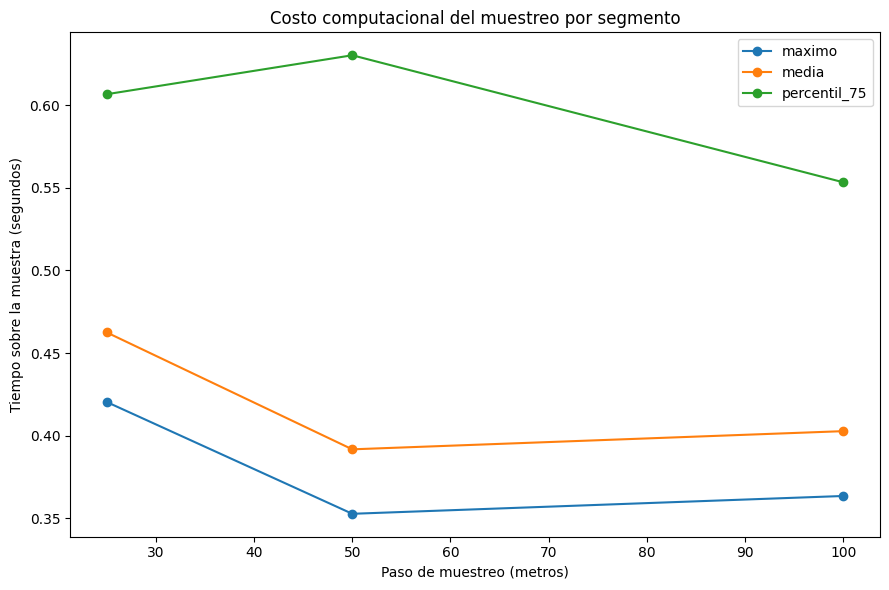

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
for agregacion, bloque in comparacion_muestreo_df.groupby('agregacion'):
    bloque = bloque.sort_values('paso_metros')
    ax.plot(
        bloque['paso_metros'],
        bloque['tiempo_segundos'],
        marker='o',
        label=agregacion,
    )
ax.set_title('Costo computacional del muestreo por segmento')
ax.set_xlabel('Paso de muestreo (metros)')
ax.set_ylabel('Tiempo sobre la muestra (segundos)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'comparacion_tiempo_muestreo.png', dpi=200)
plt.show()


### 12.1 Selección final del método por segmento

Se seleccionó un paso de muestreo de **25 metros** y la **media** como método de agregación.

Las alternativas de 50 y 100 metros presentaron correlaciones superiores a 0,99999 respecto de la referencia de 25 metros, lo que confirmó la estabilidad de la superficie. Sin embargo, se mantuvo el intervalo de menor longitud porque el tiempo de procesamiento no constituyó una restricción y ofreció la aproximación espacial de mayor resolución evaluada.

La media representa la exposición promedio a lo largo del tramo y evita que un único punto elevado determine el valor completo del segmento. El máximo y el percentil 75 produjeron distribuciones muy similares, pero incorporaban un criterio más conservador que no resultaba necesario para el objetivo comparativo del modelo.

In [27]:
filas_ier_segmentos = []

for franja, interpolador in tqdm(interpoladores_ier.items(), desc='Franjas'):
    valores = segmentos_base_gdf['geometry'].map(
        lambda geom: calcular_ier_segmento(
            geom,
            interpolador,
            paso_metros=PASO_MUESTREO_FINAL,
            metodo_agregacion=AGREGACION_FINAL,
        )
    )

    bloque = segmentos_base_gdf[['u', 'v', 'key', 'length', 'geometry']].copy()
    bloque['franja_agregada'] = franja
    bloque['valor_ier'] = valores.fillna(0.0).clip(lower=0.0, upper=1.0)
    filas_ier_segmentos.append(bloque)

ier_segmento_franjas_gdf = gpd.GeoDataFrame(
    pd.concat(filas_ier_segmentos, ignore_index=True),
    geometry='geometry',
    crs=segmentos_base_gdf.crs,
)

print('Registros segmento-franja:', f'{len(ier_segmento_franjas_gdf):,}')
display(ier_segmento_franjas_gdf.head())


Franjas:   0%|          | 0/5 [00:00<?, ?it/s]

Registros segmento-franja: 701,430


,u,v,key,length,geometry,franja_agregada,valor_ier
0,32382602,11694885382,0,52.923968,"LINESTRING (368631.681 6175823.991, 368603.529...",General,0.039779
1,32382602,667447739,0,144.241295,"LINESTRING (368631.681 6175823.991, 368598.187...",General,0.040779
2,32382602,11820158326,0,65.475010,"LINESTRING (368631.681 6175823.991, 368647.606...",General,0.037682
3,32382602,11820158197,0,47.214539,"LINESTRING (368631.681 6175823.991, 368610.774...",General,0.039160
4,11694885382,11820158212,0,43.265619,"LINESTRING (368580.582 6175838.085, 368538.494...",General,0.041078


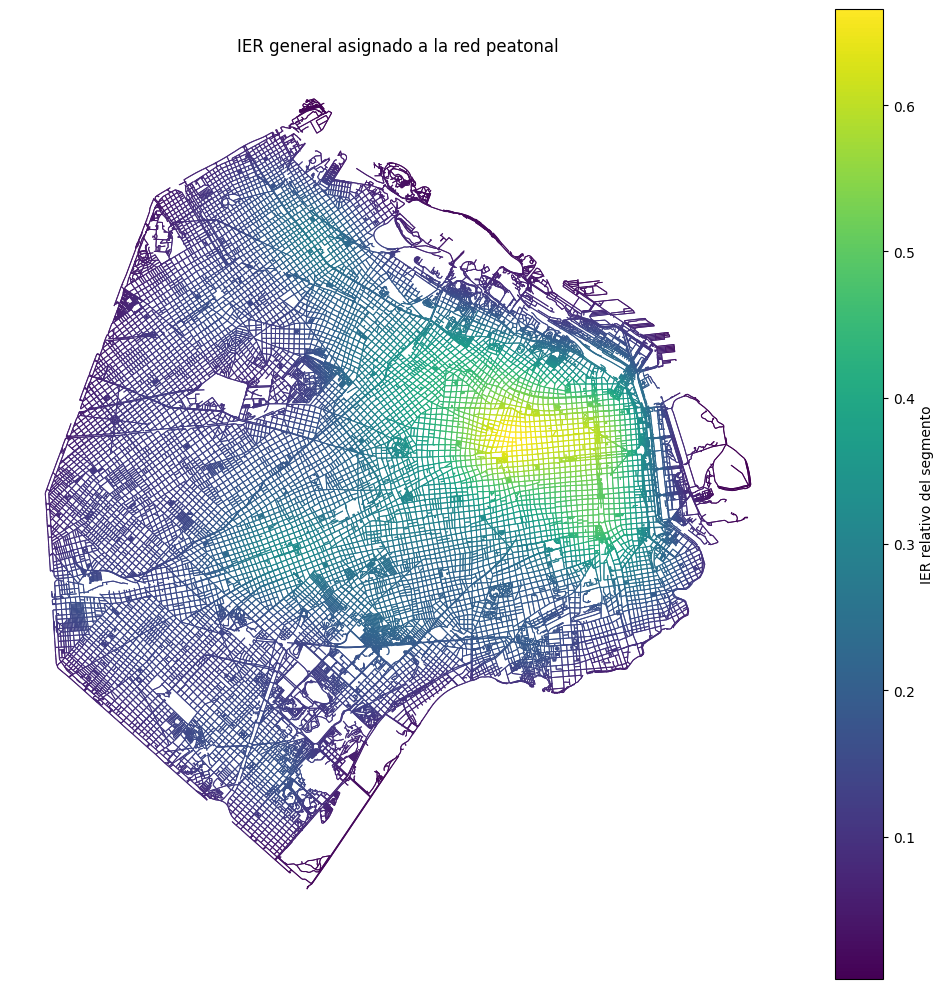

In [28]:
ier_general_gdf = ier_segmento_franjas_gdf.loc[
    ier_segmento_franjas_gdf['franja_agregada'] == 'General'
].copy()

fig, ax = plt.subplots(figsize=(10, 10))
ier_general_gdf.plot(
    ax=ax,
    column='valor_ier',
    linewidth=0.7,
    legend=True,
    legend_kwds={'label': 'IER relativo del segmento'},
)
ax.set_title('IER general asignado a la red peatonal')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ier_general_por_segmento.png', dpi=200)
plt.show()


## 13. Función de costo y calibración de `alpha`

La ruta base minimiza la longitud. La ruta alternativa minimiza una función que incrementa el costo de los segmentos según su IER:

$$
\text{costo}_{e}=\text{longitud}_{e}\times(1+\alpha\times IER_{e})
$$

- `alpha = 0` reproduce la ruta más corta;
- valores mayores aumentan la importancia relativa del IER;
- la elección se realiza comparando reducción del IER e incremento de distancia sobre múltiples trayectos.


In [29]:
def mapa_ier_para_franja(
    ier_segmentos: pd.DataFrame,
    franja: str,
) -> dict[tuple, float]:
    bloque = ier_segmentos.loc[
        ier_segmentos['franja_agregada'] == franja,
        ['u', 'v', 'key', 'valor_ier'],
    ]
    return {
        (fila.u, fila.v, fila.key): float(np.nan_to_num(fila.valor_ier, nan=0.0))
        for fila in bloque.itertuples(index=False)
    }


def configurar_costos_grafo(
    grafo: nx.MultiDiGraph,
    mapa_ier: dict[tuple, float],
    alpha: float,
) -> None:
    for u, v, key, datos in grafo.edges(keys=True, data=True):
        longitud = float(datos.get('length', 0.0) or 0.0)
        ier = float(mapa_ier.get((u, v, key), 0.0))
        datos['valor_ier'] = ier
        datos['costo_seguridad'] = longitud * (1.0 + alpha * ier)


def seleccionar_arista(
    grafo: nx.MultiDiGraph,
    u,
    v,
    atributo_peso: str,
) -> tuple[int, dict]:
    opciones = grafo.get_edge_data(u, v)
    if not opciones:
        raise nx.NetworkXNoPath(f'No existe arista entre {u} y {v}.')

    key, datos = min(
        opciones.items(),
        key=lambda item: float(item[1].get(atributo_peso, np.inf)),
    )
    return key, datos


def metricas_ruta(
    grafo: nx.MultiDiGraph,
    ruta: list,
    atributo_peso_elegido: str,
) -> dict:
    longitudes = []
    valores_ier = []

    for u, v in zip(ruta[:-1], ruta[1:]):
        _, datos = seleccionar_arista(grafo, u, v, atributo_peso_elegido)
        longitud = float(datos.get('length', 0.0) or 0.0)
        ier = float(datos.get('valor_ier', 0.0) or 0.0)
        longitudes.append(longitud)
        valores_ier.append(ier)

    distancia = float(np.sum(longitudes))
    if distancia > 0:
        ier_ponderado = float(np.average(valores_ier, weights=longitudes))
    else:
        ier_ponderado = np.nan

    return {
        'distancia_m': distancia,
        'ier_ponderado_longitud': ier_ponderado,
        'segmentos': len(longitudes),
    }


def generar_pares_prueba(
    grafo: nx.MultiDiGraph,
    cantidad: int,
    semilla: int,
) -> list[tuple]:
    rng = random.Random(semilla)
    nodos = list(grafo.nodes)
    pares = []
    intentos = 0
    max_intentos = cantidad * 100

    while len(pares) < cantidad and intentos < max_intentos:
        origen, destino = rng.sample(nodos, 2)
        intentos += 1
        try:
            if nx.has_path(grafo, origen, destino):
                pares.append((origen, destino))
        except nx.NetworkXError:
            continue

    if len(pares) < cantidad:
        print(f'Advertencia: solo se generaron {len(pares)} pares válidos.')
    return pares


In [30]:
pares_prueba = generar_pares_prueba(
    grafo_peatonal,
    cantidad=CANTIDAD_PARES_RUTA_PRUEBA,
    semilla=SEMILLA,
)

mapa_general = mapa_ier_para_franja(ier_segmento_franjas_gdf, 'General')
grafo_calibracion = grafo_peatonal.copy()

resultados_alpha = []

# La ruta base es independiente de alpha.
configurar_costos_grafo(grafo_calibracion, mapa_general, alpha=0.0)
rutas_base = {}
metricas_base = {}

for indice, (origen, destino) in enumerate(tqdm(pares_prueba, desc='Rutas base')):
    try:
        ruta_base = nx.shortest_path(
            grafo_calibracion,
            source=origen,
            target=destino,
            weight='length',
        )
        rutas_base[indice] = ruta_base
        metricas_base[indice] = metricas_ruta(
            grafo_calibracion,
            ruta_base,
            atributo_peso_elegido='length',
        )
    except nx.NetworkXNoPath:
        continue

for alpha in tqdm(ALPHAS_CANDIDATOS, desc='Valores de alpha'):
    configurar_costos_grafo(grafo_calibracion, mapa_general, alpha=alpha)

    for indice, (origen, destino) in enumerate(pares_prueba):
        if indice not in rutas_base:
            continue

        try:
            ruta_alt = nx.shortest_path(
                grafo_calibracion,
                source=origen,
                target=destino,
                weight='costo_seguridad',
            )
            met_base = metricas_base[indice]
            met_alt = metricas_ruta(
                grafo_calibracion,
                ruta_alt,
                atributo_peso_elegido='costo_seguridad',
            )

            incremento_distancia = (
                100 * (met_alt['distancia_m'] - met_base['distancia_m'])
                / met_base['distancia_m']
                if met_base['distancia_m'] > 0 else np.nan
            )
            reduccion_ier = (
                100 * (met_base['ier_ponderado_longitud'] - met_alt['ier_ponderado_longitud'])
                / met_base['ier_ponderado_longitud']
                if met_base['ier_ponderado_longitud'] > 0 else np.nan
            )

            resultados_alpha.append({
                'caso': indice + 1,
                'alpha': alpha,
                'origen': origen,
                'destino': destino,
                'distancia_base_m': met_base['distancia_m'],
                'distancia_alternativa_m': met_alt['distancia_m'],
                'incremento_distancia_pct': incremento_distancia,
                'ier_base': met_base['ier_ponderado_longitud'],
                'ier_alternativo': met_alt['ier_ponderado_longitud'],
                'reduccion_ier_pct': reduccion_ier,
                'ruta_cambio': ruta_alt != rutas_base[indice],
            })
        except nx.NetworkXNoPath:
            continue

comparacion_alpha_detalle_df = pd.DataFrame(resultados_alpha)
comparacion_alpha_resumen_df = (
    comparacion_alpha_detalle_df.groupby('alpha')
    .agg(
        casos=('caso', 'count'),
        incremento_distancia_medio_pct=('incremento_distancia_pct', 'mean'),
        incremento_distancia_mediano_pct=('incremento_distancia_pct', 'median'),
        incremento_distancia_p90_pct=('incremento_distancia_pct', lambda s: s.quantile(0.90)),
        reduccion_ier_media_pct=('reduccion_ier_pct', 'mean'),
        reduccion_ier_mediana_pct=('reduccion_ier_pct', 'median'),
        proporcion_rutas_modificadas=('ruta_cambio', 'mean'),
        proporcion_reduccion_negativa=('reduccion_ier_pct', lambda s: (s < 0).mean()),
    )
    .reset_index()
)

display(comparacion_alpha_resumen_df)
comparacion_alpha_detalle_df.to_csv(
    TABLES_DIR / 'comparacion_alpha_detalle.csv',
    index=False,
    encoding='utf-8-sig',
)
comparacion_alpha_resumen_df.to_csv(
    TABLES_DIR / 'comparacion_alpha_resumen.csv',
    index=False,
    encoding='utf-8-sig',
)


Rutas base:   0%|          | 0/30 [00:00<?, ?it/s]

Valores de alpha:   0%|          | 0/6 [00:00<?, ?it/s]

,alpha,casos,incremento_distancia_medio_pct,incremento_distancia_mediano_pct,incremento_distancia_p90_pct,reduccion_ier_media_pct,reduccion_ier_mediana_pct,proporcion_rutas_modificadas,proporcion_reduccion_negativa
0,0.0,30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.5,30,0.220933,0.000000,0.284496,3.290677,0.000000,0.333333,0.0
2,1.0,30,0.598394,0.001258,2.291068,4.869316,0.038577,0.566667,0.0
3,2.0,30,1.203817,0.228033,3.680100,7.028781,2.225122,0.666667,0.0
4,3.0,30,1.933012,0.318074,5.997256,8.696404,2.939445,0.733333,0.0
5,5.0,30,3.862173,0.931413,10.696528,11.585944,4.510026,0.766667,0.0


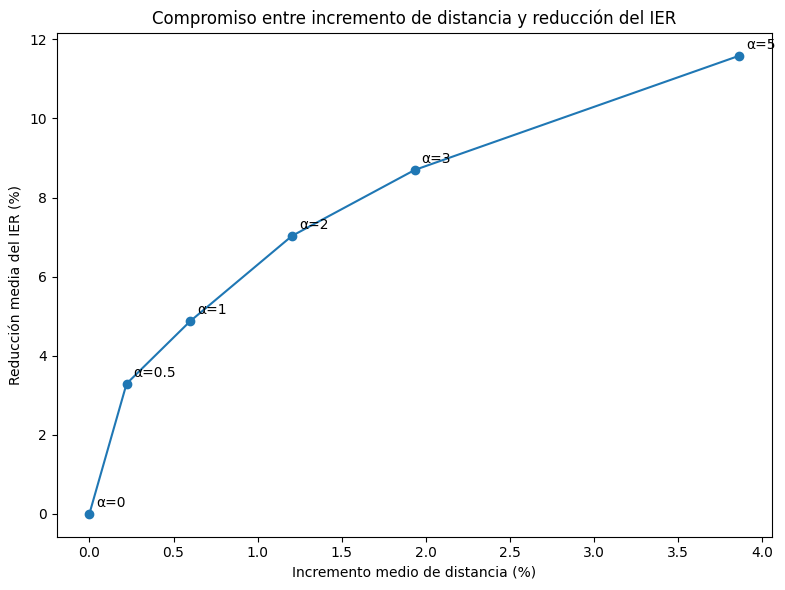

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    comparacion_alpha_resumen_df['incremento_distancia_medio_pct'],
    comparacion_alpha_resumen_df['reduccion_ier_media_pct'],
    marker='o',
)

for fila in comparacion_alpha_resumen_df.itertuples(index=False):
    ax.annotate(
        f'α={fila.alpha:g}',
        (fila.incremento_distancia_medio_pct, fila.reduccion_ier_media_pct),
        xytext=(5, 5),
        textcoords='offset points',
    )

ax.set_title('Compromiso entre incremento de distancia y reducción del IER')
ax.set_xlabel('Incremento medio de distancia (%)')
ax.set_ylabel('Reducción media del IER (%)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'compromiso_distancia_ier_alpha.png', dpi=200)
plt.show()


### 13.1 Selección final de `alpha`

Se seleccionó **alpha = 3** como equilibrio entre reducción del IER e incremento de distancia.

Sobre 30 pares origen-destino, esta configuración produjo una reducción media del IER de **8,70 %** con un incremento medio de distancia de **1,93 %**. El 73,33 % de los recorridos presentó alguna modificación y no se observaron reducciones negativas del indicador. El valor `alpha = 5` aumentó la reducción media del IER a 11,59 %, pero elevó el incremento medio de distancia a 3,86 % y el percentil 90 del desvío a 10,70 %. Por este motivo, se consideró que la mejora adicional no compensaba el aumento del recorrido.

## 14. Validación final por franja horaria

La configuración final se prueba sobre los mismos pares origen-destino para todas las franjas. Esto permite verificar que el selector temporal modifique efectivamente los costos y que los resultados permanezcan dentro de rangos razonables.


In [32]:
resultados_validacion = []
grafo_validacion = grafo_peatonal.copy()

for franja in ['General', *FRANJAS_HORARIAS.keys()]:
    mapa = mapa_ier_para_franja(ier_segmento_franjas_gdf, franja)
    configurar_costos_grafo(grafo_validacion, mapa, alpha=ALPHA_FINAL)

    for indice, (origen, destino) in enumerate(pares_prueba):
        try:
            ruta_base = nx.shortest_path(
                grafo_validacion,
                source=origen,
                target=destino,
                weight='length',
            )
            ruta_alt = nx.shortest_path(
                grafo_validacion,
                source=origen,
                target=destino,
                weight='costo_seguridad',
            )
            met_base = metricas_ruta(grafo_validacion, ruta_base, 'length')
            met_alt = metricas_ruta(grafo_validacion, ruta_alt, 'costo_seguridad')

            incremento = (
                100 * (met_alt['distancia_m'] - met_base['distancia_m'])
                / met_base['distancia_m']
                if met_base['distancia_m'] > 0 else np.nan
            )
            reduccion = (
                100 * (met_base['ier_ponderado_longitud'] - met_alt['ier_ponderado_longitud'])
                / met_base['ier_ponderado_longitud']
                if met_base['ier_ponderado_longitud'] > 0 else np.nan
            )

            resultados_validacion.append({
                'caso': indice + 1,
                'franja': franja,
                'distancia_base_m': met_base['distancia_m'],
                'distancia_alternativa_m': met_alt['distancia_m'],
                'incremento_distancia_pct': incremento,
                'ier_base': met_base['ier_ponderado_longitud'],
                'ier_alternativo': met_alt['ier_ponderado_longitud'],
                'reduccion_ier_pct': reduccion,
                'ruta_cambio': ruta_alt != ruta_base,
            })
        except nx.NetworkXNoPath:
            resultados_validacion.append({
                'caso': indice + 1,
                'franja': franja,
                'error': 'sin_camino_valido',
            })

validacion_final_df = pd.DataFrame(resultados_validacion)
display(validacion_final_df.head(20))
validacion_final_df.to_csv(
    TABLES_DIR / 'validacion_final_rutas.csv',
    index=False,
    encoding='utf-8-sig',
)


,caso,franja,distancia_base_m,distancia_alternativa_m,incremento_distancia_pct,ier_base,ier_alternativo,reduccion_ier_pct,ruta_cambio
0,1,General,10125.623855,10355.723620,2.272450,0.314218,0.291710,7.163097,True
1,2,General,12586.750279,13320.336214,5.828239,0.328914,0.214616,34.750257,True
2,3,General,15942.648439,16078.591942,0.852703,0.174613,0.166065,4.895541,True
3,4,General,2592.861890,2592.861890,0.000000,0.231618,0.231618,0.000000,False
4,5,General,14863.150701,14933.162643,0.471044,0.300052,0.288765,3.761453,True
5,6,General,9306.951026,9310.568424,0.038868,0.155248,0.155042,0.132452,True
6,7,General,5690.206239,5695.394771,0.091184,0.220342,0.219730,0.277798,True
7,8,General,9275.662769,10215.536479,10.132685,0.373383,0.233767,37.392270,True
8,9,General,10382.064196,10411.362961,0.282206,0.194133,0.191969,1.114845,True
9,10,General,15789.050861,16661.727098,5.527098,0.244171,0.187722,23.118730,True


In [33]:
resumen_validacion_franja_df = (
    validacion_final_df.dropna(subset=['incremento_distancia_pct'])
    .groupby('franja')
    .agg(
        casos=('caso', 'count'),
        incremento_distancia_medio_pct=('incremento_distancia_pct', 'mean'),
        reduccion_ier_media_pct=('reduccion_ier_pct', 'mean'),
        proporcion_rutas_modificadas=('ruta_cambio', 'mean'),
    )
    .reset_index()
)
display(resumen_validacion_franja_df)
resumen_validacion_franja_df.to_csv(
    TABLES_DIR / 'resumen_validacion_por_franja.csv',
    index=False,
    encoding='utf-8-sig',
)


,franja,casos,incremento_distancia_medio_pct,reduccion_ier_media_pct,proporcion_rutas_modificadas
0,General,30,1.933012,8.696404,0.733333
1,Madrugada,30,1.489223,8.365860,0.600000
2,Mañana,30,1.544101,7.092697,0.700000
3,Noche,30,2.287319,9.303707,0.733333
4,Tarde,30,3.204741,11.801747,0.733333


## 15. Exportación de datos, modelos y artefactos

La exportación conserva una separación entre datos originales, datos procesados, tablas metodológicas y archivos requeridos por la aplicación.


In [34]:
# Dataset consolidado y limpio.
trabajo_df.to_csv(
    DATA_PROCESSED_DIR / 'delitos_consolidados_con_estados.csv',
    index=False,
    encoding='utf-8-sig',
)

delitos_limpios_df.to_csv(
    DATA_PROCESSED_DIR / 'delitos_utilizables_modelo.csv',
    index=False,
    encoding='utf-8-sig',
)

# Superficies e información de grilla.
np.savez_compressed(
    MODELS_DIR / 'superficies_ier.npz',
    centros_x=centros_x,
    centros_y=centros_y,
    bordes_x=bordes_x,
    bordes_y=bordes_y,
    **{f'ier_{normalizar_nombre_columna(k)}': v for k, v in superficies_ier.items()},
)

# IER por segmento en WGS84 para Streamlit/Folium.
ier_segmento_franjas_wgs84_gdf = ier_segmento_franjas_gdf.to_crs(CRS_COORDENADAS)
SEGMENTOS_FINAL_PATH = MODELS_DIR / 'segmentos_ier_wgs84.pkl'
ier_segmento_franjas_wgs84_gdf.to_pickle(SEGMENTOS_FINAL_PATH)

# Asignar el IER general como atributo inicial del grafo.
mapa_general_final = mapa_ier_para_franja(ier_segmento_franjas_gdf, 'General')
configurar_costos_grafo(grafo_peatonal, mapa_general_final, alpha=ALPHA_FINAL)

GRAFO_FINAL_PATH = MODELS_DIR / 'grafo_peatonal_con_ier.pkl'
with open(GRAFO_FINAL_PATH, 'wb') as archivo:
    pickle.dump(grafo_peatonal, archivo, protocol=pickle.HIGHEST_PROTOCOL)

# Copia de artefactos dentro de la carpeta de la aplicación.
shutil.copy2(GRAFO_FINAL_PATH, APP_DIR / GRAFO_FINAL_PATH.name)
shutil.copy2(SEGMENTOS_FINAL_PATH, APP_DIR / SEGMENTOS_FINAL_PATH.name)

parametros_finales = {
    'crs_coordenadas': CRS_COORDENADAS,
    'crs_metrico': CRS_METRICO,
    'tamanio_celda_m': TAMANIO_CELDA_FINAL,
    'bandwidth_m': BANDWIDTH_FINAL,
    'margen_m': MARGEN_METROS,
    'paso_muestreo_segmento_m': PASO_MUESTREO_FINAL,
    'agregacion_segmento': AGREGACION_FINAL,
    'alpha': ALPHA_FINAL,
    'franjas_horarias': FRANJAS_HORARIAS,
    'semilla': SEMILLA,
}

with open(MODELS_DIR / 'parametros_finales.json', 'w', encoding='utf-8') as archivo:
    json.dump(parametros_finales, archivo, ensure_ascii=False, indent=2)

print('Artefactos exportados:')
print('-', GRAFO_FINAL_PATH)
print('-', SEGMENTOS_FINAL_PATH)
print('-', MODELS_DIR / 'superficies_ier.npz')


Artefactos exportados:
- C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales\outputs\models\grafo_peatonal_con_ier.pkl
- C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales\outputs\models\segmentos_ier_wgs84.pkl
- C:\Users\atvid\Downloads\TFG-RUTAS-PEATONALES-REPO\tfg-rutas-peatonales\outputs\models\superficies_ier.npz


## 16. Aplicación Streamlit

La interfaz del prototipo se mantiene como un archivo independiente en `app/app.py`. El notebook exporta a esa carpeta el grafo peatonal y el conjunto de segmentos con IER por franja horaria.

Una vez generados los artefactos, la aplicación se inicia desde la raíz del repositorio mediante:

```bash
streamlit run app/app.py
```

La aplicación permite ingresar origen y destino, seleccionar una franja horaria, comparar la ruta base con la ruta ponderada y visualizar sus métricas.

## 17. Limitaciones y decisiones metodológicas

### Limitaciones de los datos

- La estructura y las categorías de las fuentes pueden cambiar entre años.
- Los hechos con coordenadas faltantes, inválidas o fuera del rango analizado no pueden incorporarse al cálculo espacial.
- La disponibilidad de la hora del hecho varía entre archivos.
- Los registros oficiales pueden estar afectados por subregistro y diferencias en los procesos de denuncia o clasificación.
- La frecuencia histórica de hechos no representa por sí sola todos los factores vinculados con la seguridad peatonal.

### Limitaciones del modelo

- El IER es relativo a las fuentes, la ventana temporal y los parámetros seleccionados.
- El modelo base no asigna pesos distintos según la tipología delictiva.
- El KDE suaviza la distribución de los eventos y no reproduce barreras físicas o límites urbanos de manera exacta.
- La ampliación de la grilla reduce el truncamiento del filtro, pero no compensa la ausencia de registros de jurisdicciones externas a CABA.
- La función de costo expresa un compromiso regulado por `alpha`; no existe una única ruta objetivamente óptima para todos los usuarios.
- Los resultados deben interpretarse como una herramienta comparativa y no como una garantía de seguridad.

### Dependencias externas

- La red peatonal depende de la cobertura y actualización de OpenStreetMap.
- La geocodificación de direcciones puede requerir servicios externos y conexión a internet.
- La versión prototipada no posee garantías de disponibilidad, escalabilidad o soporte propias de un sistema productivo.

## 18. Síntesis de resultados

- **Archivos históricos incorporados:** 10, correspondientes al período 2016–2025.
- **Registros originales consolidados:** 1.387.622.
- **Registros utilizables para el análisis general:** 1.353.037 (97,51 %).
- **Registros utilizables para franjas horarias:** 1.350.831 (97,35 %).
- **Tamaño de celda:** 100 metros.
- **Bandwidth:** 750 metros.
- **Margen de la grilla:** 3000 metros.
- **Paso de muestreo por segmento:** 25 metros.
- **Método de agregación:** media.
- **Alpha:** 3.
- **Incremento medio de distancia en la validación general:** 1,93 %.
- **Reducción media del IER en la validación general:** 8,70 %.
- **Rutas modificadas en la validación general:** 73,33 %.

Los resultados muestran que la ponderación del IER permitió reducir la exposición relativa estimada con incrementos moderados de distancia en el conjunto de recorridos evaluado. La validez de estas métricas se limita a las fuentes, parámetros y casos de prueba utilizados.